In [1]:
# instalações
!pip install matplotlib==3.5.2

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import folium
from folium.plugins import HeatMap
import plotly.figure_factory as ff
from scipy.cluster import hierarchy
import numpy as np
import statsmodels.api as sm
from sklearn.preprocessing import LabelEncoder

In [3]:
base = pd.read_csv('dataset_novos_cursos_2.csv', encoding='Latin1', sep=';')
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 38 columns):
 #   Column                                                                                                                                                                                                                                  Non-Null Count  Dtype 
---  ------                                                                                                                                                                                                                                  --------------  ----- 
 0   Carimbo de data/hora                                                                                                                                                                                                                    92 non-null     object
 1   Qual a sua situação atual em relação ao curso ?                                                                 

O conjunto de dados é formado apenas por características categóricas, impossibilitando realizar alguns plots de dados, porém, é possível extrair alguns insights. A variável Carimbo de data/hora será removido do conjunto de dados, esse dado é apenas para manter o registro temporal em que foi respondido o dado 

In [ ]:
base.head()

,Carimbo de data/hora,Qual a sua situação atual em relação ao curso ?,Qual a sua Universidade,Qual o estado onde se localiza sua universidade,Qual o curso que você ingressou?,Em qual turno você estava matriculado?,Em qual ano e semestre você ingressou no curso? Exemplo 2010.1,Em qual semestre você concluiu ou desistiu do curso? Exemplo 2015.2,"Em relação ao seu aproveitamento acadêmico, até o segundo semestre do curso você foi?","Com relação ao ingresso na universidade a qual se matriculou, esta sempre foi a sua primeira opção de Universidade?",...,"Perguntas sobre fatores individuas, internos à instituição e externos à instituição [Em relação à cadeia de pré-requisitos das disciplinas do curso, você considera adequada?]","Perguntas sobre fatores individuas, internos à instituição e externos à instituição [Em relação aos critérios de avaliação do desempenho do aluno, você considera adequado?]","Perguntas sobre fatores individuas, internos à instituição e externos à instituição [Em relação à infraestrutura da instituição como laboratórios, bibliotecas, equipamentos de informática e etc, você considera adequada?]","Perguntas sobre fatores individuas, internos à instituição e externos à instituição [Em relação aos professores, você considera que os mesmos apresentam deficiências pedagógicas, desinteresse ou outros problemas?]","Perguntas sobre fatores individuas, internos à instituição e externos à instituição [Você considera que as carreiras relacionadas ao curso são socialmente reconhecidas?]","Perguntas sobre fatores individuas, internos à instituição e externos à instituição [Em relação ao mercado, você considera que o profissional formado no curso que você escolheu, é pago adequadamente?]","Perguntas sobre fatores individuas, internos à instituição e externos à instituição [Durante o período em que você estava na universidade, seus pais eram casados?]","Ao ingressar na universidade, qual era a renda mensal da sua família?","Em relação à sua mãe, qual o nível de escolaridade dela?","Em relação ao seu pai, qual o nível de escolaridade dele?"
0,2022/04/12 10:09:09 AM GMT-3,Concludente,NaN,NaN,Biotecnologia,Diurno,2016.1,2022.1,Reprovado em uma disciplina,"Sim, sempre quis cursar o ensino superior na U...",...,Não,Não,Não,Sim,Não,Não,Sim,Acima de 3000 reais,Ensino médio completo,Ensino superior Completo
1,2022/04/12 10:48:13 AM GMT-3,Concludente,NaN,NaN,Biotecnologia,Diurno,2016.1,2021.2,Reprovado em três disciplinas,"Não, a UFERSA foi a única Universidade que con...",...,Sim,Sim,Não,Sim,Não,Sim,Sim,Entre 2001 e 2500 reais,Ensino superior Completo,Ensino médio completo
2,2022/04/12 5:06:08 PM GMT-3,Evadido/Desistente,NaN,NaN,Engenharia Agrícola e Ambiental,Diurno,2019.1,2021.2,Reprovado em cinco ou mais disciplinas,"Não, a UFERSA foi a minha segunda opção de Un...",...,Sim,Sim,Não,Sim,Não,Não,Sim,Entre 1501 e 2000 reais,Ensino médio completo,Ensino médio completo
3,2022/04/12 8:04:47 PM GMT-3,Concludente,NaN,NaN,Engenharia Agrícola e Ambiental,Diurno,2015.2,2021.1,Reprovado em duas disciplinas,"Não, a UFERSA foi a minha segunda opção de Un...",...,Não,Sim,Não,Sim,Não,Não,Não,Entre 501 e 1000 reais,Ensino médio completo,Ensino fundamental incompleto
4,2022/04/21 5:57:12 PM GMT-3,Evadido/Desistente,NaN,NaN,Biotecnologia,Diurno,2016.1,2017.1,Aprovado em todas as disciplinas,"Sim, sempre quis cursar o ensino superior na U...",...,Sim,Não,Sim,Sim,Não,Sim,Sim,Acima de 3000 reais,Ensino superior Completo,Ensino superior Completo


# **Análise Univariada**

## Qual a situação atual em relação ao curso?

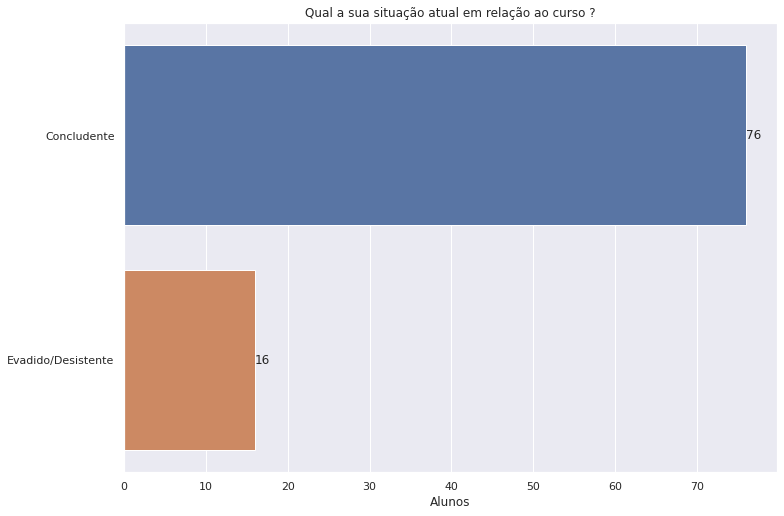

In [ ]:
sns.set(rc={'figure.figsize':(11.7,8.27)})
ax = sns.countplot(y = base.iloc[:,1],
              data = base,
              order = base.iloc[:,1].value_counts()[:10].index)
width = 0.35
valores = base.iloc[:,1].value_counts()[:10].values
ax.bar_label(container=ax.containers[0], labels=valores)
ax.set_ylabel('')
ax.set_xlabel('Alunos')
ax.set_title(base.iloc[:,1].name)
## Salvando figura
fig = ax.get_figure()
fig.savefig('1.1 - situação no curso - Cursos Biotecnologia e Engenharia ambiental.png',bbox_inches='tight')
plt.show()

In [ ]:
situacaovalores = base.iloc[:,1].value_counts()
situacaopercentual = base.iloc[:,1].value_counts(normalize=True).round(2) * 100
dfsistuacao = pd.DataFrame({'Contagem': situacaovalores, 'Frequência':situacaopercentual})
dfsistuacao.reset_index(inplace=True )
dfsistuacao.columns = ['Situação', 'Contagem', 'Frequência (%)']
dfsistuacao.style.set_caption("Alunos - Biotec e Ambiental")

,Situação,Contagem,Frequência (%)
0,Concludente,76,83.000000
1,Evadido/Desistente,16,17.000000


Esse conjunto de dados é predominante por alunos que concluíram o curso, vale descatar que isso torna o problema deslanceado já que o número mínimo de alunos evadidos/desistentes é bem menor comparado com os concludentes. 82% (76) da base de dados são de alunos concludentes e 18% (16) são de alunos evasores ou desistentes.

## Qual o volume dos alunos distribuídos pelas instituições?

In [ ]:
# tratamento dos dados ausentes
base.iloc[:,2].fillna('UFERSA', inplace=True)

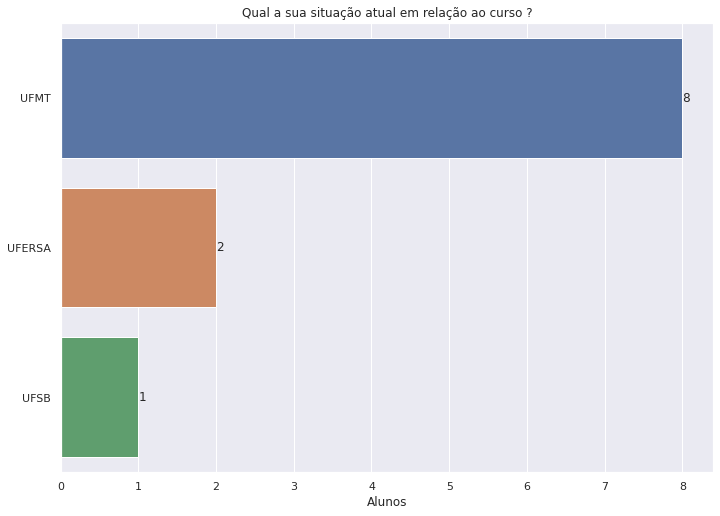

In [ ]:
ax = sns.countplot(y = base.iloc[:,2],
              data = base,
              order = base.iloc[:,2].value_counts()[:10].index)
width = 0.35
valores = base.iloc[:,2].value_counts()[:10].values
ax.bar_label(container=ax.containers[0], labels=valores)
ax.set_ylabel('')
ax.set_xlabel('Alunos')
ax.set_title(base.iloc[:,1].name)
## Salvando figura
fig = ax.get_figure()
fig.savefig('2.1 - universidade - Cursos Biotecnologia e Engenharia ambiental.png',bbox_inches='tight')
plt.show()

Em relação a instituição é possível perceber que existem 3 instituições diferentes, entre elas com 90% (83) dos alunos são da UFERSA, seguidos dos alunos da UFMT com 8% (8) da base e por último a UFSB com 2% (1) alunos.

## Qual o estado onde se localiza sua universidade?

In [ ]:
# tratamento dos dados ausentes em Qual o estado onde se localiza sua universidade
base.iloc[:,3].fillna('RN', inplace=True)

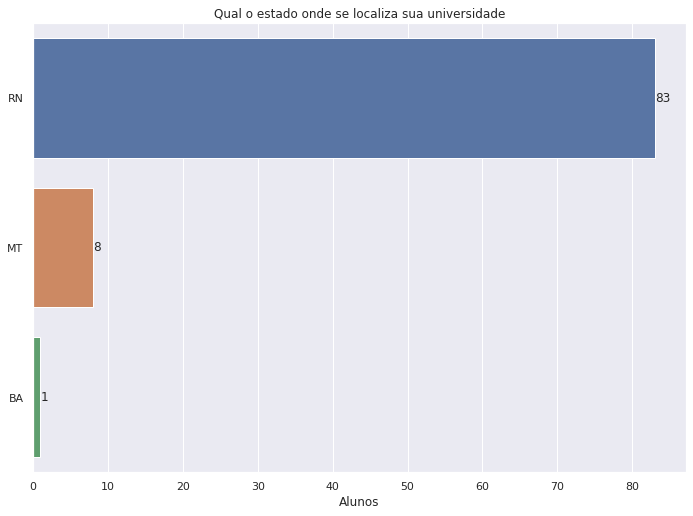

In [ ]:
ax = sns.countplot(y = base.iloc[:,3],
              data = base,
              order = base.iloc[:,3].value_counts()[:10].index)
width = 0.35
valores = base.iloc[:,3].value_counts()[:10].values
ax.bar_label(container=ax.containers[0], labels=valores)
ax.set_ylabel('')
ax.set_xlabel('Alunos')
ax.set_title(base.iloc[:,3].name)
## Salvando figura
fig = ax.get_figure()
fig.savefig('local universidade - Cursos Biotecnologia e Engenharia ambiental.png',bbox_inches='tight')
plt.show()

Em relação ao estado onde é localizado a universidade é possível perceber que existem 4 estados diferentes, entre elas com 90% (83) dos alunos são do RN, seguidos dos alunos do MT com 8% (8) da base e por último a  BA com 2% (1).


## Qual o curso que você ingressou?

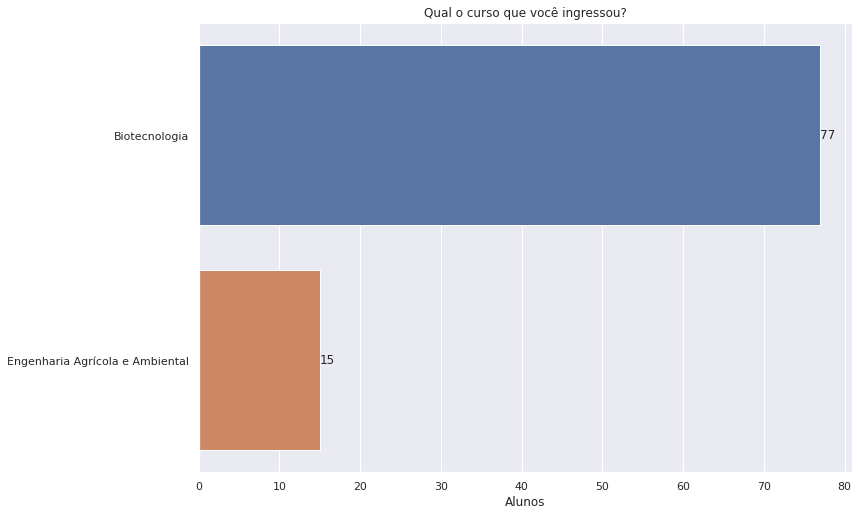

In [ ]:
ax = sns.countplot(y = base.iloc[:,4],
              data = base,
              order = base.iloc[:,4].value_counts()[:10].index)
width = 0.35
valores = base.iloc[:,4].value_counts()[:10].values
ax.bar_label(container=ax.containers[0], labels=valores)
ax.set_ylabel('')
ax.set_xlabel('Alunos')
ax.set_title(base.iloc[:,4].name)
plt.show()

In [ ]:
base.iloc[:,4].name

'Qual o curso que você ingressou?'

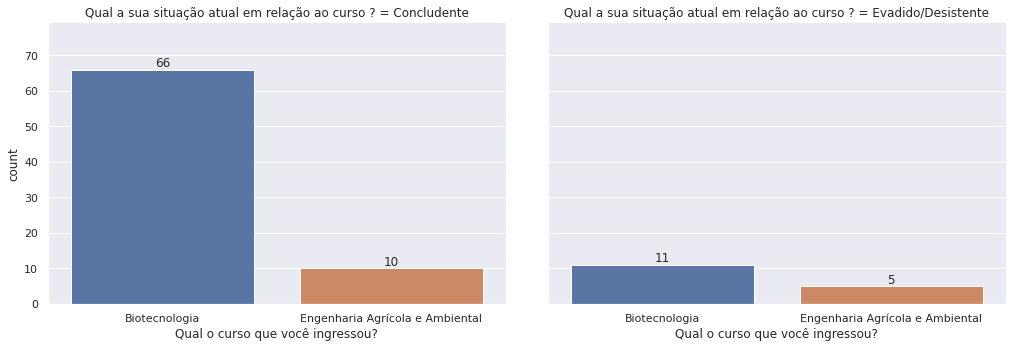

In [ ]:
g = sns.catplot(x='Qual o curso que você ingressou?', col='Qual a sua situação atual em relação ao curso ?', data=base, kind="count",col_wrap=2)
g.fig.set_size_inches(15,5)
for ax in g.axes.ravel():
    for c in ax.containers:
        labels = [f'{(v.get_height()):.0f}' for v in c]
        ax.bar_label(c, labels=labels)
    ax.margins(y=0.2)
plt.show()

Esse conjunto de dados possui dois cursos:



*   Biotecnologia com 83% (78) dos alunos 
*   Engenharia Agrícola e Ambiental com 16% (15) dos alunos

Esse conjunto se mantem desbalanceado entre as duas categorias, neste caso, é possível dificultar o aprendizado do modelo que será treinado para predizer os alunos com propensão de riscos de evadir/desistir entre os que vão concluir. 

O curso de Engenharia Agrícola e Ambiental aprensenta o maior percentual de evasão comparando-o com o curso de Biotecnologia, 33% e 14% respectivamente.



## Em qual  turno você  estava matriculado?

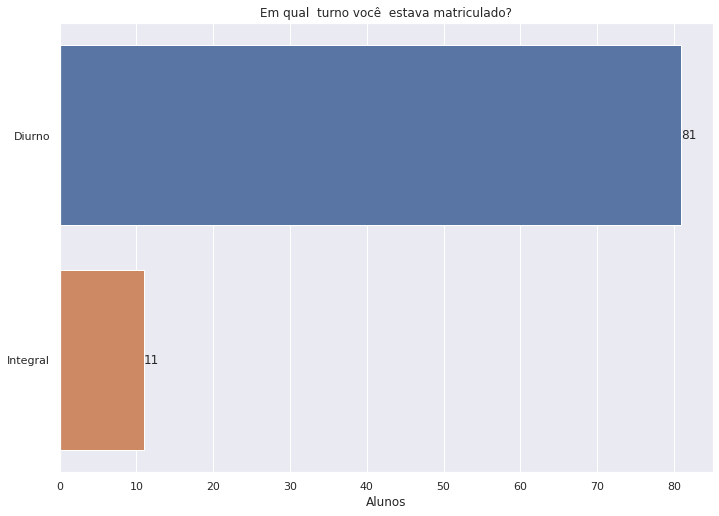

In [ ]:
ax = sns.countplot(y = base.iloc[:,5],
              data = base,
              order = base.iloc[:,5].value_counts()[:10].index)
width = 0.35
valores = base.iloc[:,5].value_counts()[:10].values
ax.bar_label(container=ax.containers[0], labels=valores)
ax.set_ylabel('')
ax.set_xlabel('Alunos')
ax.set_title(base.iloc[:,5].name)
## Salvando figura
fig = ax.get_figure()
fig.savefig('17 - turno - Cursos Biotecnologia e Engenharia ambiental.png',bbox_inches='tight')
plt.show()

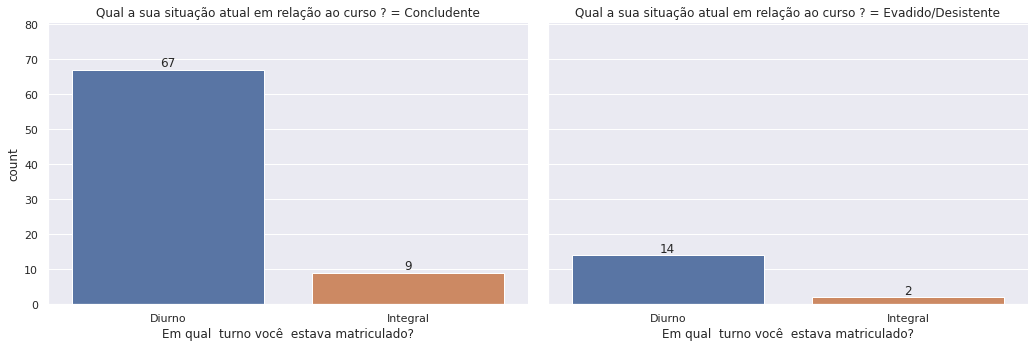

In [ ]:
g = sns.catplot(x='Em qual  turno você  estava matriculado?', col='Qual a sua situação atual em relação ao curso ?', data=base, kind="count",col_wrap=2)
g.fig.set_size_inches(15,5)
for ax in g.axes.ravel():
    for c in ax.containers:
        labels = [f'{(v.get_height()):.0f}' for v in c]
        ax.bar_label(c, labels=labels)
    ax.margins(y=0.2)
plt.show()

Em relação ao turno em que os alunos estudam 88% (81) representa o grupo de alunos do diurno e 12% (11) é referente aos estudantes de tempo integral. Ao analisar o percentual de evasão desses turnos 17% (14) dos estudantes são do turno diurno e aproximadamente 18% (2) dos alunos são do tempo integral. Vale destacar a importância do estudo em ambos os turnos, porém, existe a possibilidade de aumentar o engajamento dependendo do turno e o do tempo da turma.

## Em qual ano e semestre você ingressou no curso?

In [ ]:
# tratando alguns dados dos semestere de ingresso
base.replace('2014','2014.1', inplace=True)
base.replace('2022/1','2022.1', inplace=True)
base.replace('2019.3','2019.2', inplace=True)

In [ ]:
df2 = base.sort_values('Em qual ano e semestre você ingressou no curso? Exemplo 2010.1')

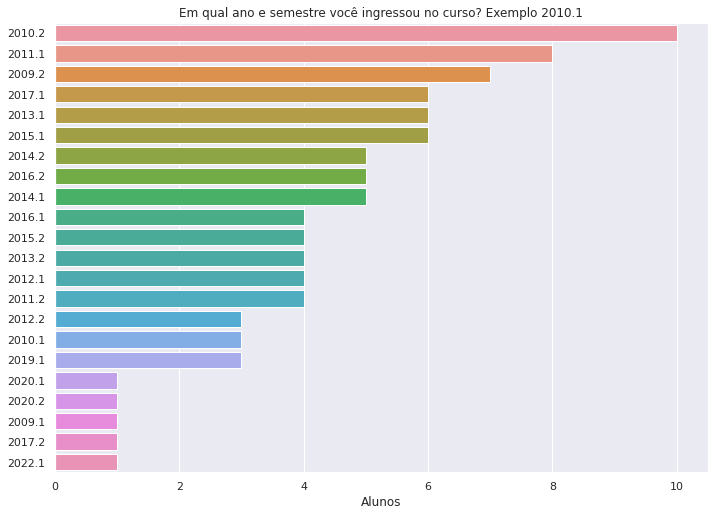

In [ ]:
ax = sns.countplot(y = df2.iloc[:,6],
              data = df2,
              order = df2.iloc[:,6].value_counts()[:30].index)#hue=df2.iloc[:,1])
#width = 0.35
#valores = base.iloc[:,6].value_counts().values
#ax.bar_label(container=ax.containers[0], labels=valores)
ax.set_ylabel('')
ax.set_xlabel('Alunos')
ax.set_title(df2.iloc[:,6].name)
## Salvando figura
fig = ax.get_figure()
fig.savefig('3.1 - ano ingresso - Cursos Biotecnologia e Engenharia ambiental.png',bbox_inches='tight')
plt.show()

Analisando a linha do tempo de ingressos de 2009 até 2022.1 é possível perceber que existem alguns intervalos que não apresentaram evasões como os alunos que entraram entre 2011 à 2013 e para os demais intervalos houve evasões. Vale destacar que nesse período os alunos que ingressaram em 2015.1 e 2019.1 apresentaram maior percentual de evasão em cada semestre com aproximadamente 18% (3 alunos).

## Em relação ao seu aproveitamento acadêmico, até o segundo semestre do curso você foi?

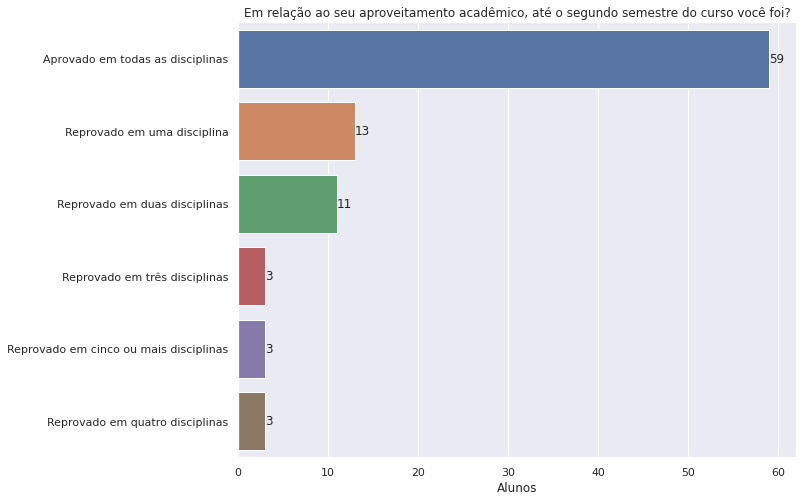

In [ ]:
ax = sns.countplot(y = base.iloc[:,8],
              data = base,
              order = base.iloc[:,8].value_counts()[:10].index)
width = 0.35
valores = base.iloc[:,8].value_counts()[:10].values
ax.bar_label(container=ax.containers[0], labels=valores)
ax.set_ylabel('')
ax.set_xlabel('Alunos')
ax.set_title(base.iloc[:,8].name)
## Salvando figura
fig = ax.get_figure()
fig.savefig('16.1 - Aproveitamento academico - Cursos Biotecnologia e Engenharia ambiental.png',bbox_inches='tight')
plt.show()

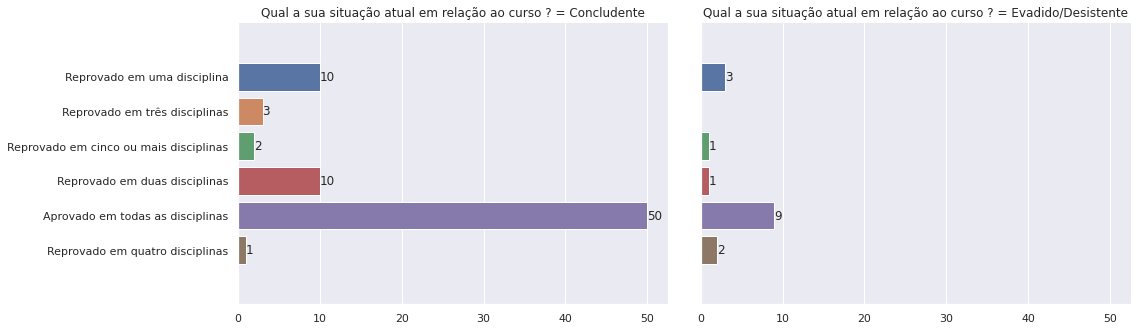

In [ ]:
g = sns.catplot(y='Em relação ao seu aproveitamento acadêmico, até o segundo semestre do curso você foi?', col='Qual a sua situação atual em relação ao curso ?', data=base, kind="count",col_wrap=2)
g.fig.set_size_inches(20,5)
for ax in g.axes.ravel():
    for c in ax.containers:
        labels = [f'{(v.get_width()):.0f}' for v in c]
        ax.bar_label(c, labels=labels)
    ax.margins(y=0.2)
g.set_axis_labels("", "")    
plt.show()

A variável categórica "Em relação ao seu aproveitamente acadêmico, até o segundo semestre do curso você foi?", possui 6 categorias que são: aprovado em todas as disciplinas, reprovado em uma disciplina, reprovado em duas disciplinas, reprovado em três disciplinas, reprovado em quatro disciplinas e reprovad em cinco disciplinas, representando respectivamente 59(65%),13(14%),11(12%),3(3%),3(3%),3(3%). Ao detalhar mais esses dados é possível perceber que o maior percentual de evasão está no conjunto de alunos que foram reprovados em 4 disciplinas 66% (2 alunos), seguido dos aprovados em todas as disciplinas 15% (9 alunos). Ser aprovado em todas as disciplinas e desistir do curso pode elencar várias fatores como: grade do curso, professores~, gestão escolar, o curso não era como imaginado, não identificou crescimento ou ingresso no mercado, dentre outros fatores.


## Com relação ao ingresso na universidade a qual se matriculou, esta sempre foi a sua primeira opção de Universidade?

In [ ]:
# Tratamento dos dados
base.iloc[:,9].replace('Sim, sempre quis cursar o ensino superior na UFERSA','Sim', inplace=True)
base.iloc[:,9].replace('Não, a UFERSA foi  a minha segunda opção de Universidade','Não', inplace=True)
base.iloc[:,9].replace('Sim, sempre quis cursar o ensino superior nesta universidade','Sim', inplace=True)
base.iloc[:,9].replace('Não, a UFERSA foi a única Universidade que consegui ingressar','Não', inplace=True)
base.iloc[:,9].replace('Não, esta foi  a minha segunda opção de Universidade','Não', inplace=True)
base.iloc[:,9].replace('Não, a UFERSA foi  a minha terceira opção de Universidade','Não', inplace=True)

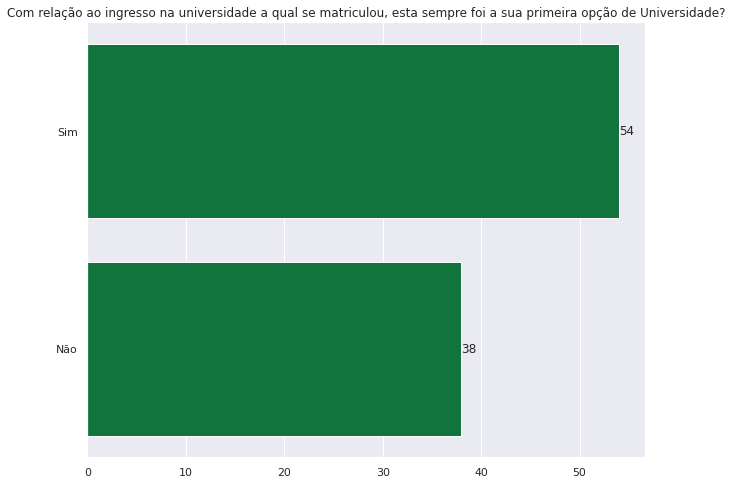

In [ ]:
sns.set(rc={'figure.figsize':(10,8)})
ax = sns.countplot(y=base.iloc[:,9], data=base, order = base.iloc[:,9].value_counts().index, color="#00853B")
valores = base.iloc[:,9].value_counts().values
ax.bar_label(container=ax.containers[0], labels=valores)
plt.title(base.iloc[:,9].name)
plt.xlabel('')
plt.ylabel('')
## Salvando figura
fig = ax.get_figure()
fig.savefig('6 - opção ingresso - Cursos Biotecnologia e Engenharia ambiental.png',bbox_inches='tight')
plt.show()

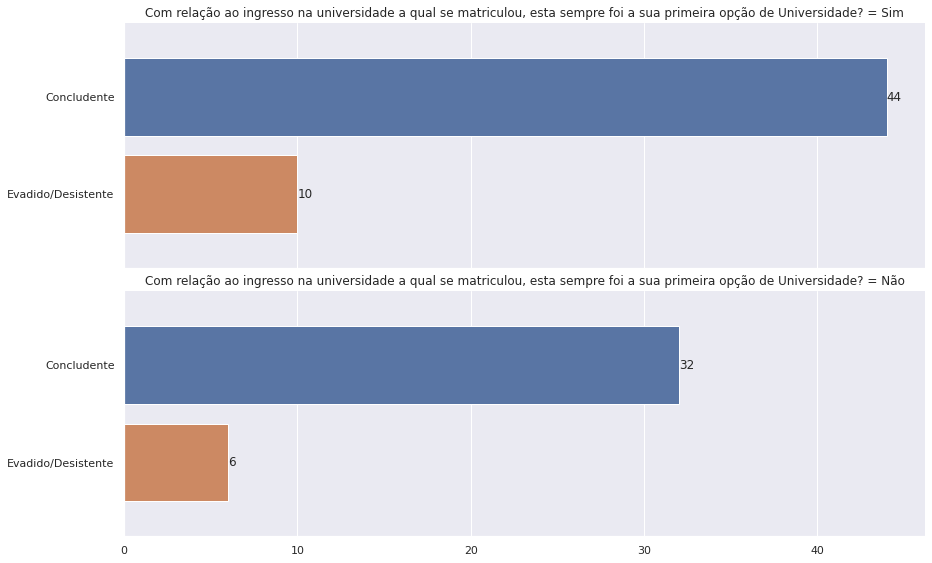

In [ ]:
g = sns.catplot(y='Qual a sua situação atual em relação ao curso ?', 
                col='Com relação ao ingresso na universidade a qual se matriculou, esta sempre foi a sua primeira opção de Universidade?', data=base, kind="count",col_wrap=1)
g.fig.set_size_inches(20,8)
for ax in g.axes.ravel():
    for c in ax.containers:
        labels = [f'{(v.get_width()):.0f}' for v in c]
        ax.bar_label(c, labels=labels)
    ax.margins(y=0.2)
g.set_axis_labels("", "")    
plt.show()

Com relação a preferência de ingresso na universidade 58% (54 alunos) informaram que a instituição foi a primeira opção, já para os demais 42% (38 alunos) declararam que não foi a primeira opção por diversos motivos. Ao analisar a evasão dessa escolha dos estudantes é possível perceber que 62% (10) dos alunos mesmo escolhendo a instituição como primeira escolha evadiram da instituição isso pode corroborar com o questionamento anterior que mesmo a maioria dos alunos sendo aprovados nas disciplinas evadem ou abandonam o curso. Vale destacar a possibilidade de identificar com mais detalhes esses fatores de evasão para esse perfil de alunos.

## Com relação ao ingresso no curso, este sempre foi a sua primeira opção de curso?

In [ ]:
# Tratamento dos dados
base.iloc[:,10].replace('Sim, sempre quis cursar este curso ao qual ingressei','Sim', inplace=True)
base.iloc[:,10].replace('Não, esse foi o curso que consegui ingressar','Não', inplace=True)

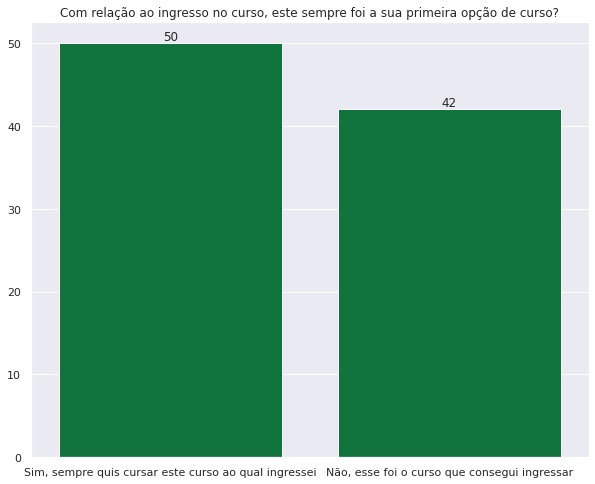

In [ ]:
sns.set(rc={'figure.figsize':(10,8)})
ax = sns.countplot(x=base.iloc[:,10], data=base, order = base.iloc[:,10].value_counts().index, color="#00853B")
valores = base.iloc[:,10].value_counts().values
ax.bar_label(container=ax.containers[0], labels=valores)
plt.title(base.iloc[:,10].name)
plt.xlabel('')
plt.ylabel('')
## Salvando figura
fig = ax.get_figure()
fig.savefig('5.1 - opção ingresso - Cursos Biotecnologia e Engenharia ambiental.png',bbox_inches='tight')
plt.show()

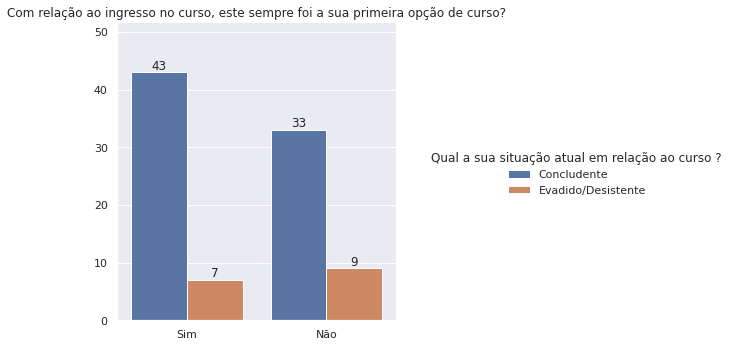

In [ ]:
g = sns.catplot(x='Com relação ao ingresso no curso, este sempre foi a sua primeira opção de curso?', 
                hue='Qual a sua situação atual em relação ao curso ?', data=base, kind="count")
g.fig.set_size_inches(10,5)
for ax in g.axes.ravel():
    for c in ax.containers:
        labels = [f'{(v.get_height()):.0f}' for v in c]
        ax.bar_label(c, labels=labels)
    ax.margins(y=0.2)
g.set_axis_labels("", "")      
plt.title('Com relação ao ingresso no curso, este sempre foi a sua primeira opção de curso?')
plt.show()

Com relação ao ingresso no curso 50 alunos (54%) informaram que a escolha foi a primeira opção e 42 alunos (46%) não entraram em sua primeira opção de curso. Se tratando dos alunos evadidos em cada um dos cenários 56% são realmente dos alunos que ingressaram em um curso que não foi de sua primeira escolha. Vale destacar que complexidade do curso, falta de entendimento e um conjunto de outros fatores favorece a não permanência do estudante encerrar o ciclo acadêmico.

BioTECH - Primeira opção


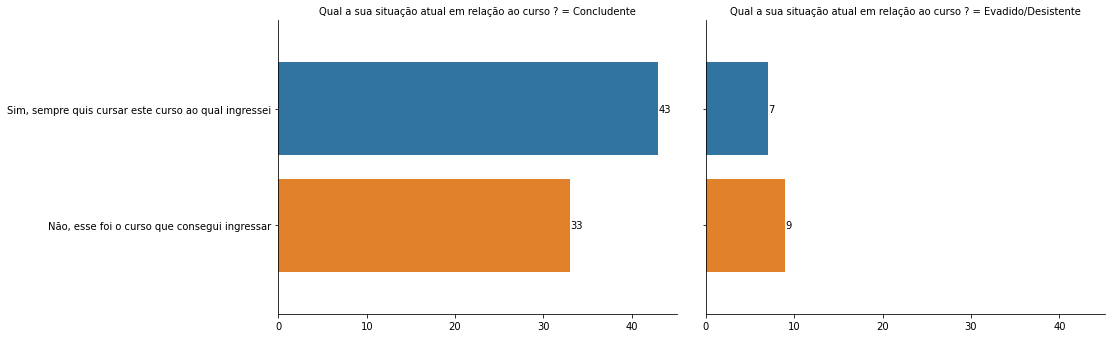

In [14]:
g = sns.catplot(y=base.iloc[:,10].name, col=base.iloc[:,1].name, data=base, kind="count",col_wrap=2)
g.fig.set_size_inches(20,5)
for ax in g.axes.ravel():
    for c in ax.containers:
        labels = [f'{(v.get_width()):.0f}' for v in c]
        ax.bar_label(c, labels=labels)
    ax.margins(y=0.2)
g.set_axis_labels("", "")    
## Salvando figura
g.savefig('aproveitamento entre concludentes e evasores.png',bbox_inches='tight')
print('BioTECH - Primeira opção')
plt.show()

## Antes de ingressar no curso, você já possuía algum conhecimento prévio na área?

In [ ]:
# tratamento nos dados
base.iloc[:,11].replace('Sim, curso técnico ou curso de formação', 'Sim', inplace=True)
base.iloc[:,11].replace('Sim, já trabalhava na área a qual estudei', 'Sim', inplace=True)

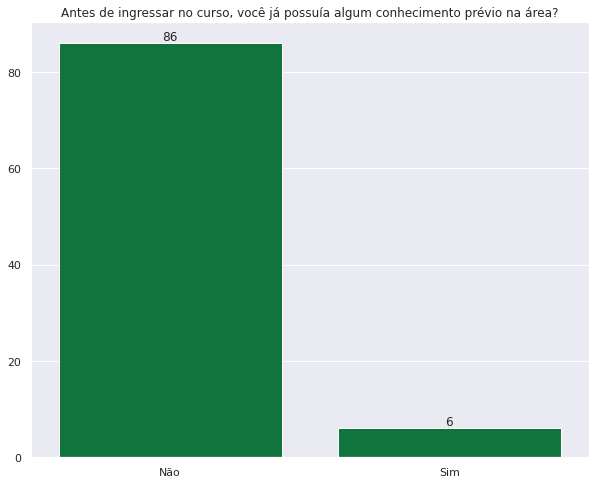

In [ ]:
sns.set(rc={'figure.figsize':(10,8)})
ax = sns.countplot(x=base.iloc[:,11], data=base, order = base.iloc[:,11].value_counts().index, color="#00853B")
valores = base.iloc[:,11].value_counts().values
ax.bar_label(container=ax.containers[0], labels=valores)
plt.title(base.iloc[:,11].name)
plt.xlabel('')
plt.ylabel('')
## Salvando figura
fig = ax.get_figure()
fig.savefig('6.1 - conhecimento prévio - Cursos Biotecnologia e Engenharia ambiental.png',bbox_inches='tight')
plt.show()

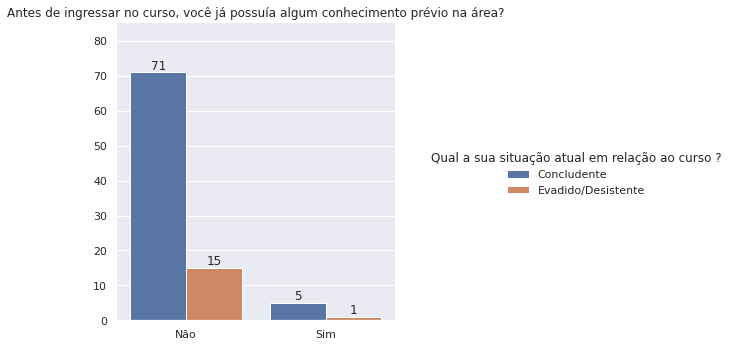

In [ ]:
g = sns.catplot(x='Antes de ingressar no curso, você já possuía algum conhecimento prévio na área?', 
                hue='Qual a sua situação atual em relação ao curso ?', data=base, kind="count")
g.fig.set_size_inches(10,5)
for ax in g.axes.ravel():
    for c in ax.containers:
        labels = [f'{(v.get_height()):.0f}' for v in c]
        ax.bar_label(c, labels=labels)
    ax.margins(y=0.2)
g.set_axis_labels("", "")      
plt.title('Antes de ingressar no curso, você já possuía algum conhecimento prévio na área?')
plt.show()

Sobre o conhecimento técnico antes de ingressar no curso cerca de 93% (86) dos alunos não possuem nenhum prévio aplicável ao curso, neste caso, é um fato comum já que boa parte dos alunos são oriundos do ensino médio e escolas técnicas, profissionalizantes ou de mesmo seguimento não possui vagas para toda a população e isso pode corroborar com essa disparidade entre os dois grupos. Se trantando do grupo dos evasores 93% (15) desses alunos não tinha nenhum conhecimento técnico sobre o curso, isso só reforça o contexto supracitada.

BioTECH - Conhecimento prévio


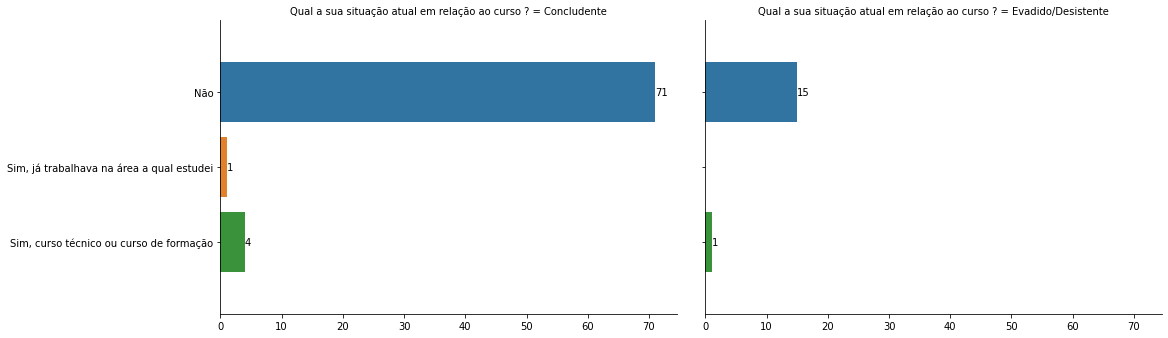

In [10]:
g = sns.catplot(y=base.iloc[:,11].name, col=base.iloc[:,1].name, data=base, kind="count",col_wrap=2)
g.fig.set_size_inches(20,5)
for ax in g.axes.ravel():
    for c in ax.containers:
        labels = [f'{(v.get_width()):.0f}' for v in c]
        ax.bar_label(c, labels=labels)
    ax.margins(y=0.2)
g.set_axis_labels("", "")    
## Salvando figura
g.savefig('aproveitamento entre concludentes e evasores.png',bbox_inches='tight')
print('BioTECH - Conhecimento prévio')
plt.show()

## Antes de ingressar na universidade, em que tipo de escola você cursou o ensino médio?

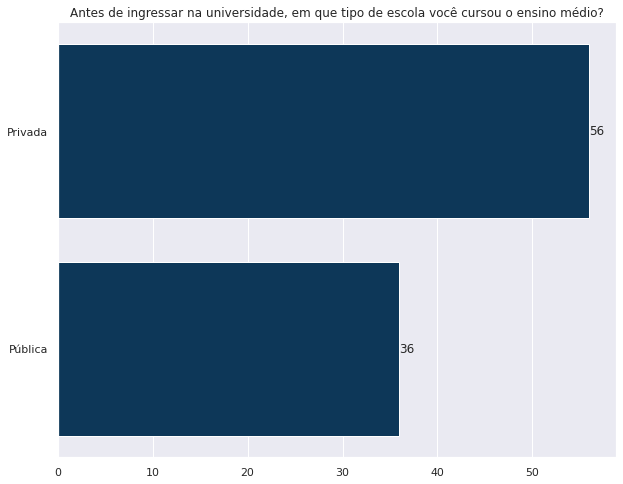

In [ ]:
ax = sns.countplot(y=base.iloc[:,12], data=base, order = base.iloc[:,12].value_counts().index, color="#003865")
valores = base.iloc[:,12].value_counts().values
ax.bar_label(container=ax.containers[0], labels=valores)
plt.title(base.iloc[:,12].name)
plt.xlabel('')
plt.ylabel('')
## Salvando figura
fig = ax.get_figure()
fig.savefig('8 - antes da universidade - Cursos Biotecnologia e Engenharia ambiental.png',bbox_inches='tight')
plt.show()

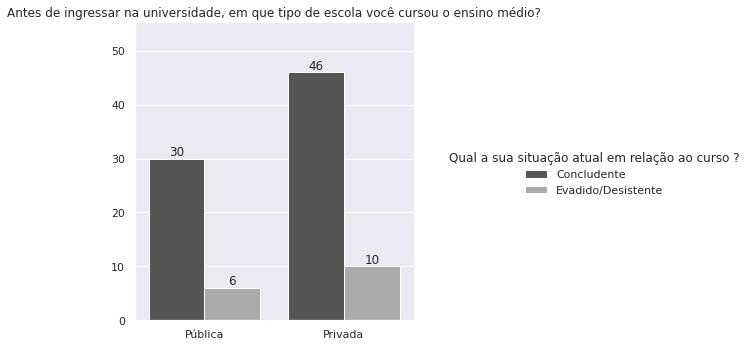

In [ ]:
g = sns.catplot(x='Antes de ingressar na universidade, em que tipo de escola você cursou o ensino médio?', 
                hue='Qual a sua situação atual em relação ao curso ?', data=base, kind="count", palette='gist_gray')
g.fig.set_size_inches(10,5)
for ax in g.axes.ravel():
    for c in ax.containers:
        labels = [f'{(v.get_height()):.0f}' for v in c]
        ax.bar_label(c, labels=labels)
    ax.margins(y=0.2)
g.set_axis_labels("", "")      
plt.title('Antes de ingressar na universidade, em que tipo de escola você cursou o ensino médio?')
plt.show()

Antes de ingressar na universidade 60% (56) dos alunos são oriundos de instituições privadas, já 40% (36) dos alunos são de instituiçõs públicas. Vale destacar que 62% (10) dos alunos que evadiram são de instituição privada. 

BioTECH - Ensino médio


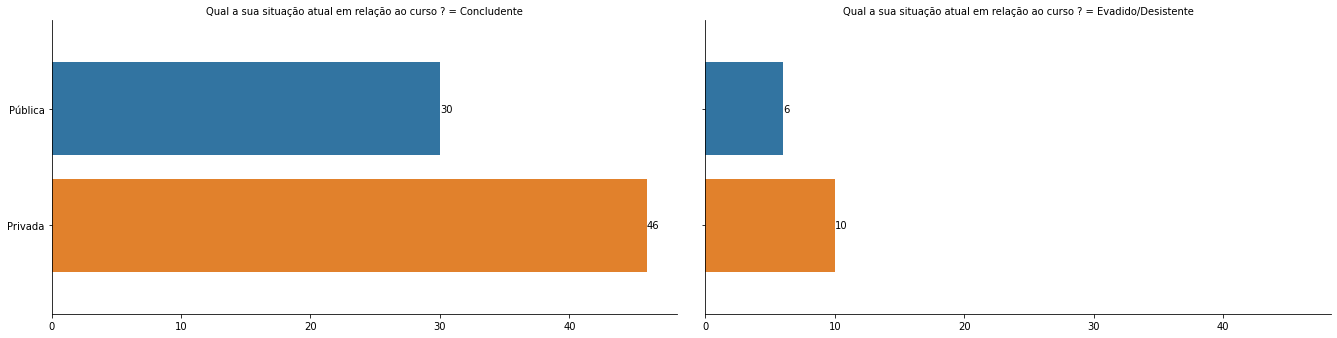

In [9]:
g = sns.catplot(y=base.iloc[:,12].name, col=base.iloc[:,1].name, data=base, kind="count",col_wrap=2)
g.fig.set_size_inches(20,5)
for ax in g.axes.ravel():
    for c in ax.containers:
        labels = [f'{(v.get_width()):.0f}' for v in c]
        ax.bar_label(c, labels=labels)
    ax.margins(y=0.2)
g.set_axis_labels("", "")    
## Salvando figura
g.savefig('aproveitamento entre concludentes e evasores.png',bbox_inches='tight')
print('BioTECH - Ensino médio')
plt.show()

## Caso tenha cursado o ensino médio em escola pública, qual foi o tipo de instituição?

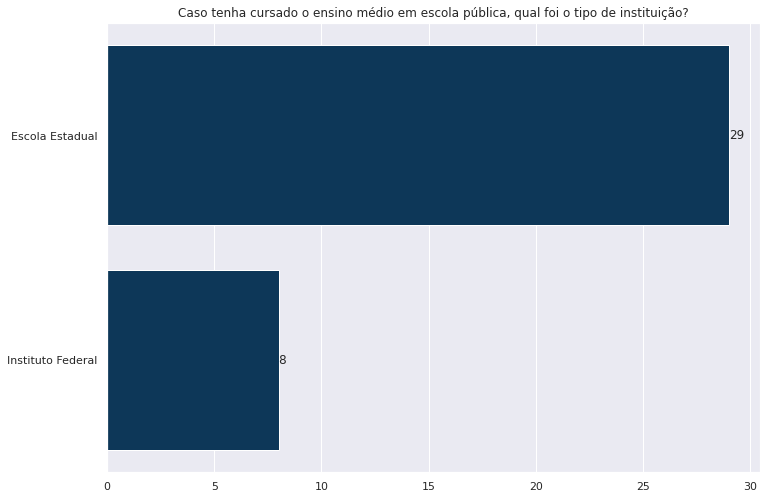

In [ ]:
ax = sns.countplot(y=base.iloc[:,13], data=base, order = base.iloc[:,13].value_counts().index, color="#003865")
valores = base.iloc[:,13].value_counts().values
ax.bar_label(container=ax.containers[0], labels=valores)
plt.title(base.iloc[:,13].name)
plt.xlabel('')
plt.ylabel('')
## Salvando figura
fig = ax.get_figure()
fig.savefig('18 - ensino médio - Cursos Biotecnologia e Engenharia ambiental.png',bbox_inches='tight')
plt.show()

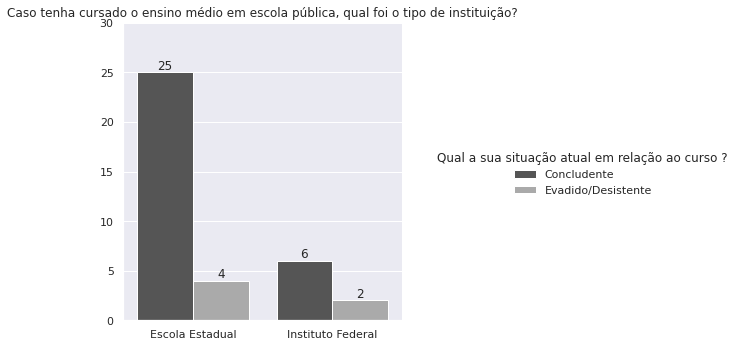

In [ ]:
g = sns.catplot(x='Caso tenha cursado o ensino médio em escola pública, qual foi o tipo de instituição?', 
                hue='Qual a sua situação atual em relação ao curso ?', data=base, kind="count", palette='gist_gray')
g.fig.set_size_inches(10,5)
for ax in g.axes.ravel():
    for c in ax.containers:
        labels = [f'{(v.get_height()):.0f}' for v in c]
        ax.bar_label(c, labels=labels)
    ax.margins(y=0.2)
g.set_axis_labels("", "")      
plt.title('Caso tenha cursado o ensino médio em escola pública, qual foi o tipo de instituição?')
plt.show()

<font color='red'>Aqui tem 37 alunos, isso é um erro, era para ser 36 pq na pergunta anterior possui apenas 36 alunos que são de 
origem pública.</font>




## Antes de ingressar no ensino médio, em que tipo de escola você cursou o ensino fundamental?

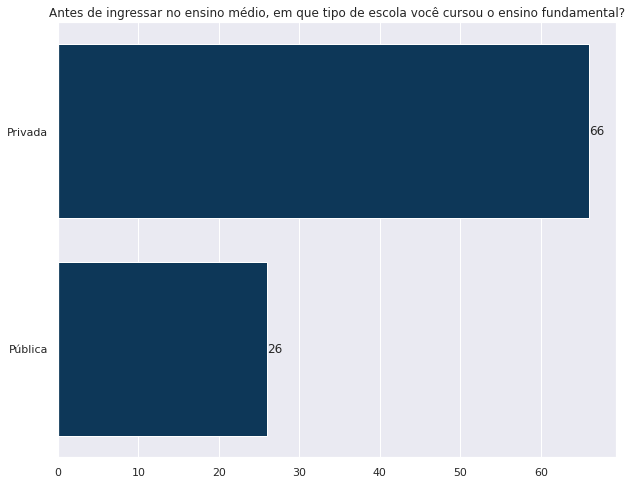

In [ ]:
ax = sns.countplot(y=base.iloc[:,14], data=base, order = base.iloc[:,14].value_counts().index, color="#003865")
valores = base.iloc[:,14].value_counts().values
ax.bar_label(container=ax.containers[0], labels=valores)
plt.title(base.iloc[:,14].name)
plt.xlabel('')
plt.ylabel('')
plt.show()

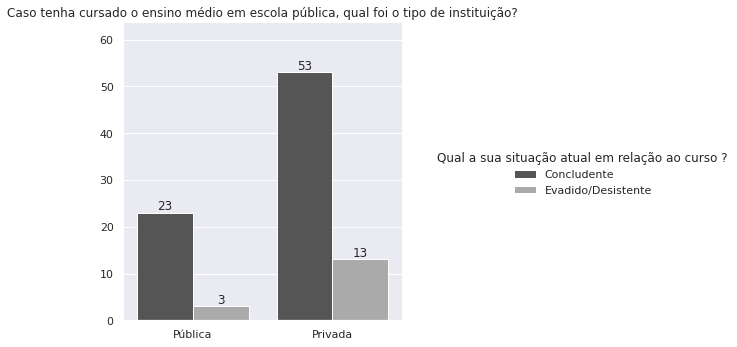

In [ ]:
g = sns.catplot(x='Antes de ingressar no ensino médio, em que tipo de escola você cursou o ensino fundamental?', 
                hue='Qual a sua situação atual em relação ao curso ?', data=base, kind="count", palette='gist_gray')
g.fig.set_size_inches(10,5)
for ax in g.axes.ravel():
    for c in ax.containers:
        labels = [f'{(v.get_height()):.0f}' for v in c]
        ax.bar_label(c, labels=labels)
    ax.margins(y=0.2)
g.set_axis_labels("", "")      
plt.title('Caso tenha cursado o ensino médio em escola pública, qual foi o tipo de instituição?')
plt.show()

Os alunos desse conjunto de dados esturadam em dois tipos de instituições: 71% (66) dos alunos são do ensino privado e 29%(26) dos alunos são do ensino público, desse universo 81% (13) dos alunos que evadiram são fizeram o ensino fundamental em instituições privadas, neste caso, existem diversos fatores que podem levar para esse cenário, entre eles: normalmente pais que colocam seus filhos em instituições privadas querem um ensino diferenciado, os filhos entendem que existe suporte da família para escolher outros cursos ou até mesmo entrar na estatística dos alunos nem nem, nem estuda e nem trabalha.

## Caso tenha cursado o ensino fundamental em escola pública, qual foi o tipo de instituição?

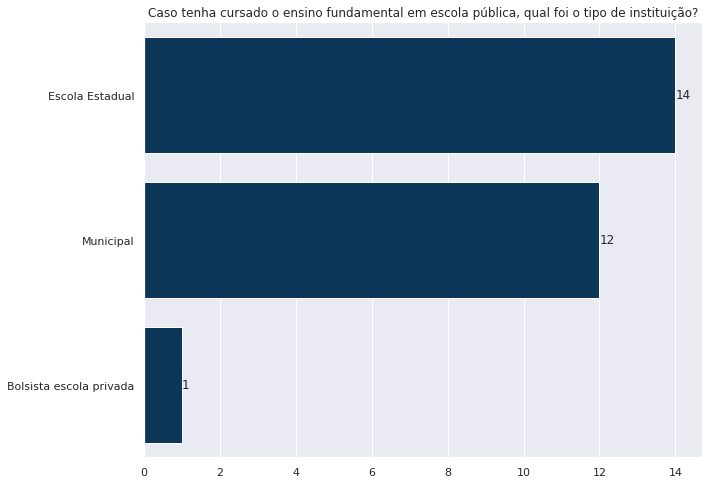

In [ ]:
ax = sns.countplot(y=base.iloc[:,15], data=base, order = base.iloc[:,15].value_counts().index, color="#003865")
valores = base.iloc[:,15].value_counts().values
ax.bar_label(container=ax.containers[0], labels=valores)
plt.title(base.iloc[:,15].name)
plt.xlabel('')
plt.ylabel('')

## Salvando figura
fig = ax.get_figure()
fig.savefig('7.1 -fundamental - Cursos Biotecnologia e Engenharia ambiental.png',bbox_inches='tight')
plt.show()

<font color='red'>Aqui tem 27 alunos, isso é um erro, era para ser 26 pq na pergunta anterior possui apenas 26 alunos que são de 
origem pública.</font>


## Antes de ingressar na universidade, você morava na mesma cidade onde se localiza o curso ao qual se matriculou?

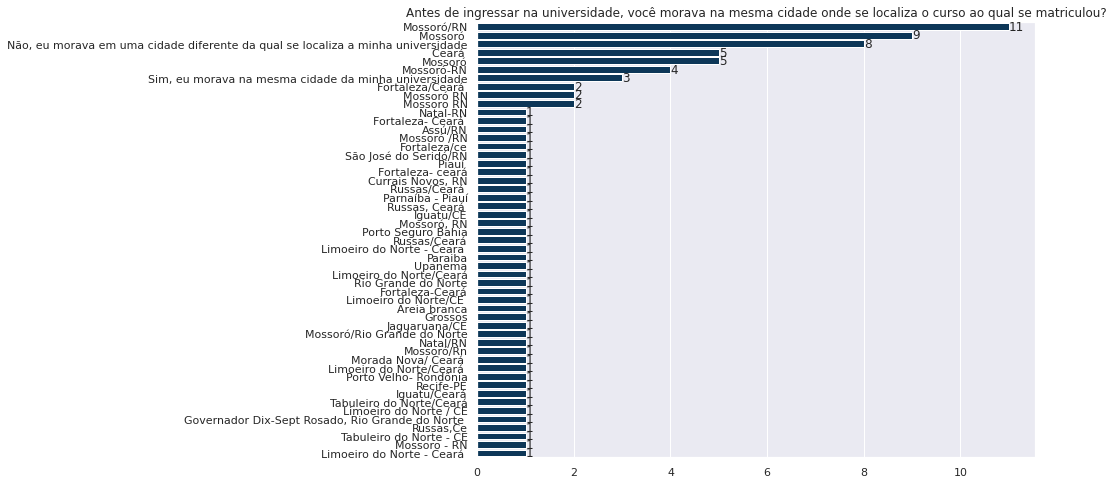

In [ ]:
ax = sns.countplot(y=base.iloc[:,16], data=base, order = base.iloc[:,16].value_counts().index, color="#003865")
valores = base.iloc[:,16].value_counts().values
ax.bar_label(container=ax.containers[0], labels=valores)
plt.title(base.iloc[:,16].name)
plt.xlabel('')
plt.ylabel('')
plt.show()

<font color='red'>Essa característica era para ser binária, porém, não é, mas um outro fato é que só tem 51 registros, pouco mais da metade do conjunto preenchido, uma alternativa é colocar todo mundo que preencheu identificar se sim e não e os que não preencheram o que deve ser feito? Será feito a coleta? Acredito que faça mais sentido analisar os dados da próxima pergunta.</font>

Ao ingressar na universidade você se mudou para morar na mesma cidade do campus que se matriculou?

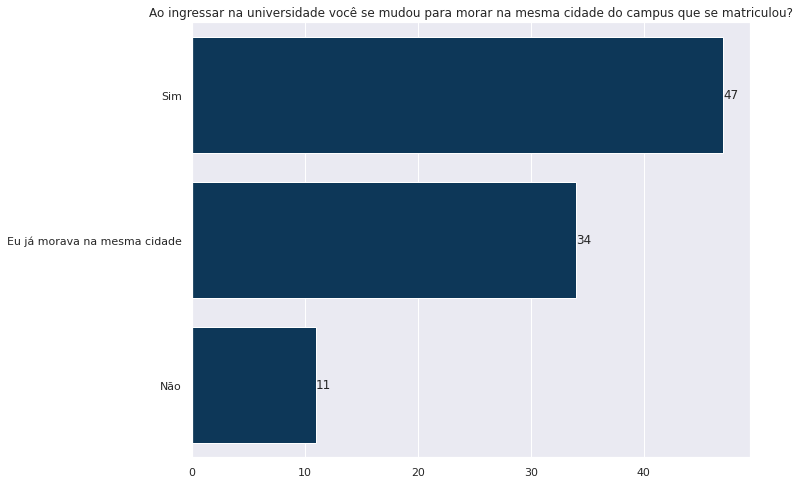

In [ ]:
coluna = 17
ax = sns.countplot(y=base.iloc[:,coluna], data=base, order = base.iloc[:,coluna].value_counts().index, color="#003865")
valores = base.iloc[:,coluna].value_counts().values
ax.bar_label(container=ax.containers[0], labels=valores)
plt.title(base.iloc[:,coluna].name)
plt.xlabel('')
plt.ylabel('')

## Salvando figura
fig = ax.get_figure()
fig.savefig('8.1 - mudou para cidade do campus - Cursos Biotecnologia e Engenharia ambiental.png',bbox_inches='tight')
plt.show()

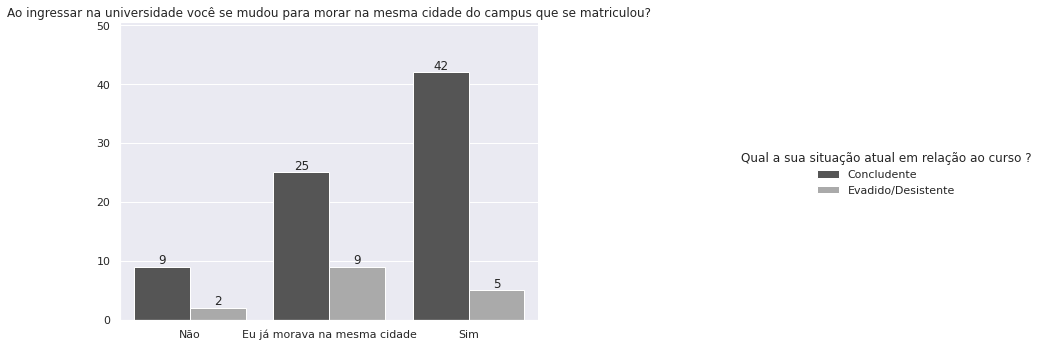

In [ ]:
coluna = 17
g = sns.catplot(x=base.iloc[:,coluna].name, 
                hue=base.iloc[:,1].name, data=base, kind="count", palette='gist_gray')
g.fig.set_size_inches(15,5)
for ax in g.axes.ravel():
    for c in ax.containers:
        labels = [f'{(v.get_height()):.0f}' for v in c]
        ax.bar_label(c, labels=labels)
    ax.margins(y=0.2)
g.set_axis_labels("", "")      
plt.title(base.iloc[:,coluna].name)
plt.show()

Ao ingressar na universidade
52% (47) dos alunos precisou residenciar na mesma cidade do campus, já 36%(35) dos alunos já morava na mesma cidade e os 12% (11) dos alunos não precisou sair de sua cidade para ir para as aulas do campus. Falando sobre evasão 56% (9) dos alunos já residem na mesma cidade do campus, isso destaca que o fator distância não é um fator de desistência ou abandono para esse conjunto de dados, já que boa parte dos evadidos já residem na mesma cidade do campus, Vale destacar que apenas 12% (2) dos evadidos não mudaram sua cidade, cenário interessante já que normalmente esses alunos precisam de algumas horas para sair de sua cidade e chegar até o campus.

## Você chegou a morar em vila acadêmica?

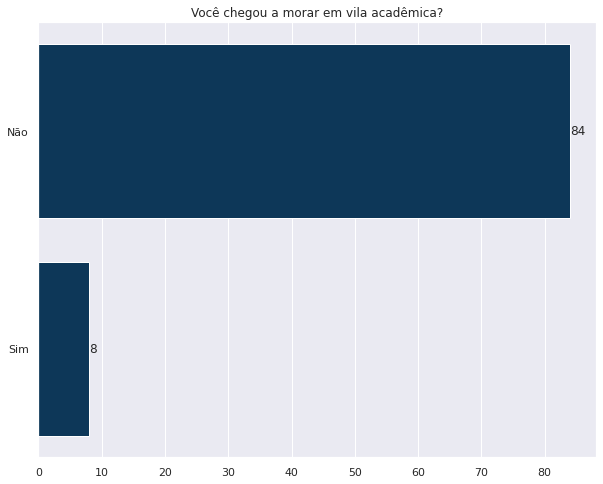

In [ ]:
coluna = 18
ax = sns.countplot(y=base.iloc[:,coluna], data=base, order = base.iloc[:,coluna].value_counts().index, color="#003865")
valores = base.iloc[:,coluna].value_counts().values
ax.bar_label(container=ax.containers[0], labels=valores)
plt.title(base.iloc[:,coluna].name)
plt.xlabel('')
plt.ylabel('')
plt.show()

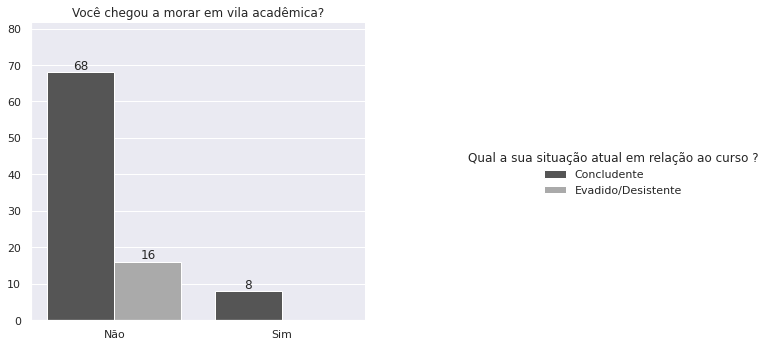

In [ ]:
coluna = 18
g = sns.catplot(x=base.iloc[:,coluna].name, 
                hue=base.iloc[:,1].name, data=base, kind="count", palette='gist_gray')
g.fig.set_size_inches(12,5)
for ax in g.axes.ravel():
    for c in ax.containers:
        labels = [f'{(v.get_height()):.0f}' for v in c]
        ax.bar_label(c, labels=labels)
    ax.margins(y=0.2)
g.set_axis_labels("", "")      
plt.title(base.iloc[:,coluna].name)
plt.show()

Alguns campus oferece aos alunos a oportunidade de residir uma temporada na vila acadêmica, passando por esse ponto 91% (84) dos alunos não residem na vila acadêmica, já 9% (8) dos alunos aproveitaram as vagas disponíveis, assim como também facilitaria o deslocamento para instituição. Vale destacar que Nenhum aluno que residiu na vila acadêmica evadiu/desistiu do curso, diferente dos alunos que não residem na vila, sendo 100%(16) dos alunos evadiram do curso. Alunos que optam por residir na vila acadêmica por muitas vezes possui um perfil mais "carente", sendo avaliado por suas característica socioeconomicas, como renda familiar, cidade onde resite, nível academico dos pais, entre outros fatores. Esses cenários por muitas vezes são motivadores para o aluno "mudar" sua situação e consequentemente de sua família através do desenvolvimento educacional.

## Qual seu gênero?

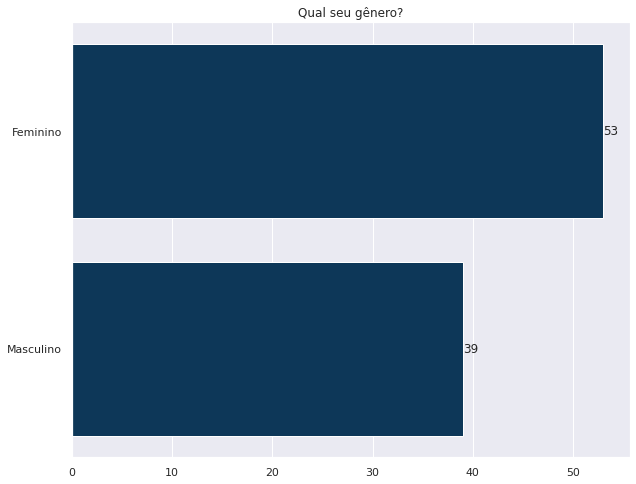

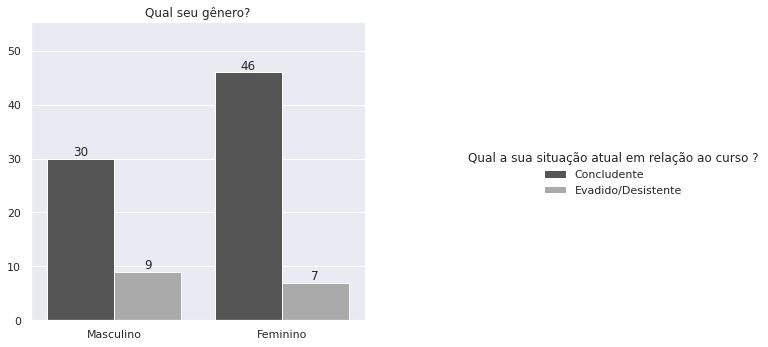

In [ ]:
coluna = 19
ax = sns.countplot(y=base.iloc[:,coluna], data=base, order = base.iloc[:,coluna].value_counts().index, color="#003865")
valores = base.iloc[:,coluna].value_counts().values
ax.bar_label(container=ax.containers[0], labels=valores)
plt.title(base.iloc[:,coluna].name)
plt.xlabel('')
plt.ylabel('')
plt.show()


g = sns.catplot(x=base.iloc[:,coluna].name, 
                hue=base.iloc[:,1].name, data=base, kind="count", palette='gist_gray')
g.fig.set_size_inches(12,5)
for ax in g.axes.ravel():
    for c in ax.containers:
        labels = [f'{(v.get_height()):.0f}' for v in c]
        ax.bar_label(c, labels=labels)
    ax.margins(y=0.2)
g.set_axis_labels("", "")      
plt.title(base.iloc[:,coluna].name)
plt.show()

Sobre o gênero 57% (53) dos alunos são do sexo feminino e 43% (39) são do sexo masculino. Assim como a distribuição próxima entre os percentuais de feminino e masculino a evasão apresenta um quadro parecido, neste caso, as pessoas do sexo masculino estão com 56% (9) de evasão e já as pessoas do sexo feminino com 44% (7) de evasão. Existem alguns dados estatísticos do IBGE que apresenta no geral as pessoas do sexo feminino ingressam mais na universidade e por sua maioria em relação aos homens são as que completam as fases educacionais, um outro ponto, é que a distribuição de pessoas do sexo feminino é maior do que das pessoas do sexo masculino.

## A qual raça você se considera pertencer?

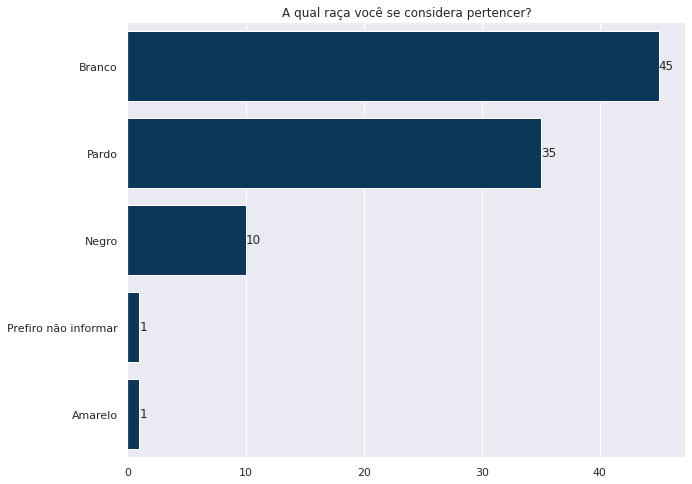

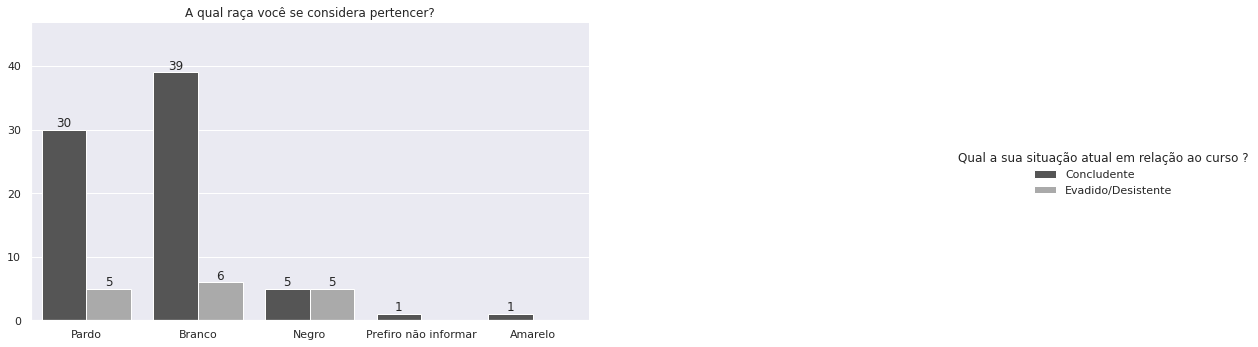

In [ ]:
coluna = 20
ax = sns.countplot(y=base.iloc[:,coluna], data=base, order = base.iloc[:,coluna].value_counts().index, color="#003865")
valores = base.iloc[:,coluna].value_counts().values
ax.bar_label(container=ax.containers[0], labels=valores)
plt.title(base.iloc[:,coluna].name)
plt.xlabel('')
plt.ylabel('')

## Salvando figura
fig = ax.get_figure()
fig.savefig('9.1 - raça - Cursos Biotecnologia e Engenharia ambiental.png',bbox_inches='tight')
plt.show()


g = sns.catplot(x=base.iloc[:,coluna].name, 
                hue=base.iloc[:,1].name, data=base, kind="count", palette='gist_gray')
g.fig.set_size_inches(20,5)
for ax in g.axes.ravel():
    for c in ax.containers:
        labels = [f'{(v.get_height()):.0f}' for v in c]
        ax.bar_label(c, labels=labels)
    ax.margins(y=0.2)
g.set_axis_labels("", "")      
plt.title(base.iloc[:,coluna].name)
plt.show()

Os alunos informaram sobre a raça que se consideram, neste conjunto de dados, é possível identificar que é predominado por pessoas que consideram-se brancas, seguidos dos pardos, negros, prefiro não informar  com os respectivos percentuais 49% (45 alunos), 38% (35 alunos), 11%(10 alunos),1% (1 aluno) e 1% (1 aluno). Falando sobre a evasão escolar é possível destacar que 37% da evasão são dos alunos que consideram-se brancos, seguidos dos alunos que consideram-se negros com 31%, se fosse analisar apenas o universo dos alunos que consideram-se negros 100% deles evadiram. Ao analisar os dados do IBGE é possível mensurar que a evasão para as pessoas negras é bem maior em relação as demais raças, isso pode ser explicado por diversas formas ao estudar os dados sociodemográficos de todos os estudantes negros.

## Quando estava matriculado na universidade, qual era o seu Estado Civil?

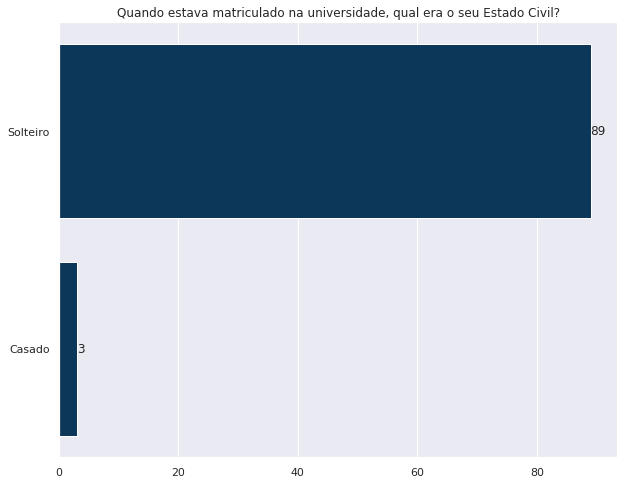

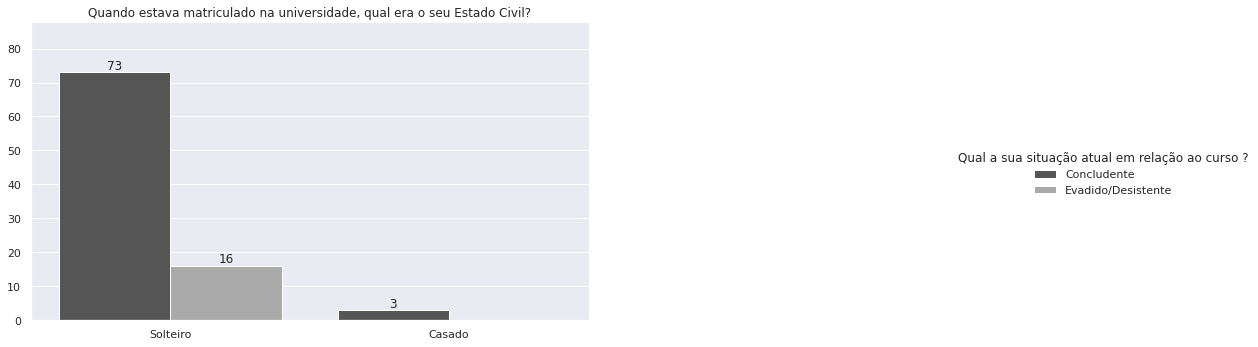

In [ ]:
coluna = 21
ax = sns.countplot(y=base.iloc[:,coluna], data=base, order = base.iloc[:,coluna].value_counts().index, color="#003865")
valores = base.iloc[:,coluna].value_counts().values
ax.bar_label(container=ax.containers[0], labels=valores)
plt.title(base.iloc[:,coluna].name)
plt.xlabel('')
plt.ylabel('')
plt.show()


g = sns.catplot(x=base.iloc[:,coluna].name, 
                hue=base.iloc[:,1].name, data=base, kind="count", palette='gist_gray')
g.fig.set_size_inches(20,5)
for ax in g.axes.ravel():
    for c in ax.containers:
        labels = [f'{(v.get_height()):.0f}' for v in c]
        ax.bar_label(c, labels=labels)
    ax.margins(y=0.2)
g.set_axis_labels("", "")      
plt.title(base.iloc[:,coluna].name)
plt.show()

Durante a vida acadêmica as pessoas podem passar por estado cívil diferente, neste caso, foi analisado o estado cívil dos alunos ao ingressar na universidade e foi possível mensurar que 96% (89) dos estudantes são solteiros e apenas pífios 4% (3) são casados. Um ponto em destaque é que mesmo com as obrigações matrimoniais e responsabilidades que são adventos do casamento, 100% (3) dos estudantes casados concluíram o curso, ou seja, todos os estudantes solteiros evadiram-se da instituição. 

## Quando ingressou na universidade, qual era o sua idade?

In [ ]:
# tratamento na base de dados
base.iloc[:,22].replace(['18 anos','17 anos','19 anos', 'Entre 20 e 25 anos', 'Acima de 25 anos'],['<= 18 anos','<= 18 anos', '> 18 anos','> 18 anos', '> 18 anos'], inplace=True)

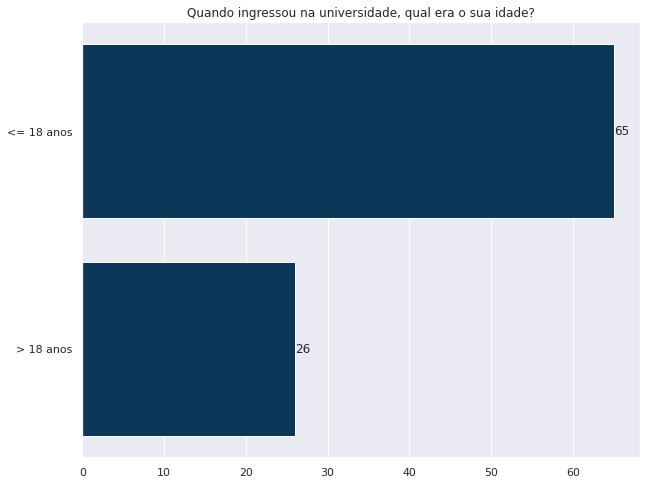

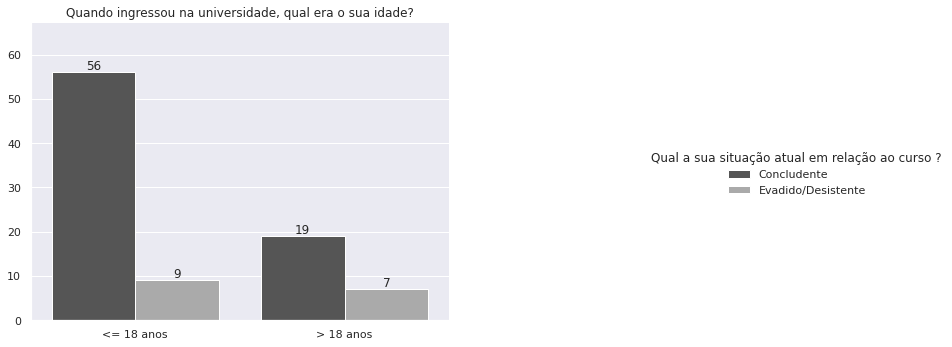

In [ ]:
coluna = 22
ax = sns.countplot(y=base.iloc[:,coluna], data=base, order = base.iloc[:,coluna].value_counts().index, color="#003865")
valores = base.iloc[:,coluna].value_counts().values
ax.bar_label(container=ax.containers[0], labels=valores)
plt.title(base.iloc[:,coluna].name)
plt.xlabel('')
plt.ylabel('')
plt.show()


g = sns.catplot(x=base.iloc[:,coluna].name, 
                hue=base.iloc[:,1].name, data=base, kind="count", palette='gist_gray')
g.fig.set_size_inches(15,5)
for ax in g.axes.ravel():
    for c in ax.containers:
        labels = [f'{(v.get_height()):.0f}' for v in c]
        ax.bar_label(c, labels=labels)
    ax.margins(y=0.2)
g.set_axis_labels("", "")      
plt.title(base.iloc[:,coluna].name)
plt.show()

Sobre a idade dos ingressos 70% (65) da base é composta por estudantes que possui até 18 anos e 30% (26) dos estudantes possuem mais de 18 anos, ao comparar com a evasão os números também são bem próximos 56% (9) para os estudantes mais jovens com menos de 18 anos e 44% (7) para os estudantes mais velhos com mais de 18 anos. Estudantes mais jovens tendem a desistir com uma certa frequência dos cursos, por muitas vezes estar descobrindo qual é a sua paixão.

## Perguntas sobre fatores individuas, internos à instituição e externos à instituição [Quando estava na universidade, você tinha filhos?]

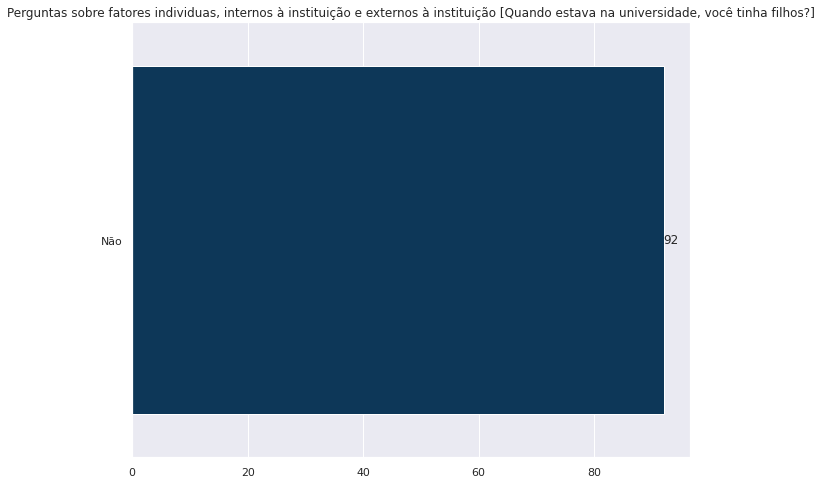

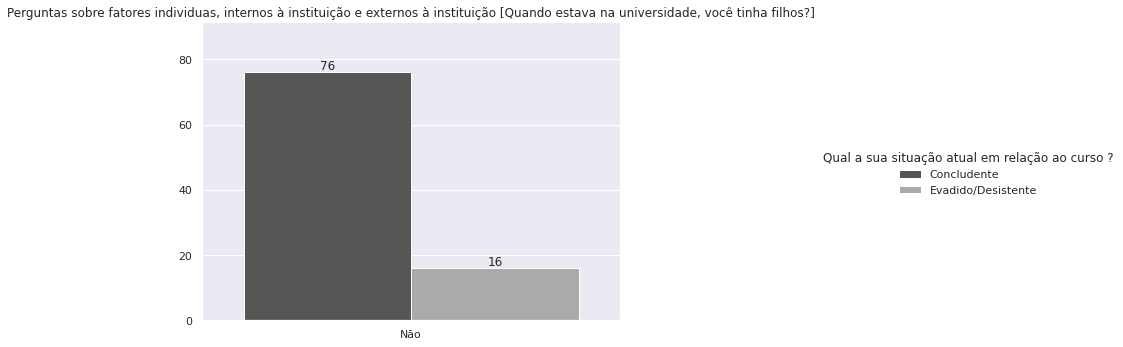

In [ ]:
coluna = 23
ax = sns.countplot(y=base.iloc[:,coluna], data=base, order = base.iloc[:,coluna].value_counts().index, color="#003865")
valores = base.iloc[:,coluna].value_counts().values
ax.bar_label(container=ax.containers[0], labels=valores)
plt.title(base.iloc[:,coluna].name)
plt.xlabel('')
plt.ylabel('')
## Salvando figura
fig = ax.get_figure()
fig.savefig('10.1 - filhos - Cursos Biotecnologia e Engenharia ambiental.png',bbox_inches='tight')
plt.show()


g = sns.catplot(x=base.iloc[:,coluna].name, 
                hue=base.iloc[:,1].name, data=base, kind="count", palette='gist_gray')
g.fig.set_size_inches(15,5)
for ax in g.axes.ravel():
    for c in ax.containers:
        labels = [f'{(v.get_height()):.0f}' for v in c]
        ax.bar_label(c, labels=labels)
    ax.margins(y=0.2)
g.set_axis_labels("", "")      
plt.title(base.iloc[:,coluna].name)
plt.show()

Sem discussão sobre esse conjunto de dados

BioTECH - Filhos


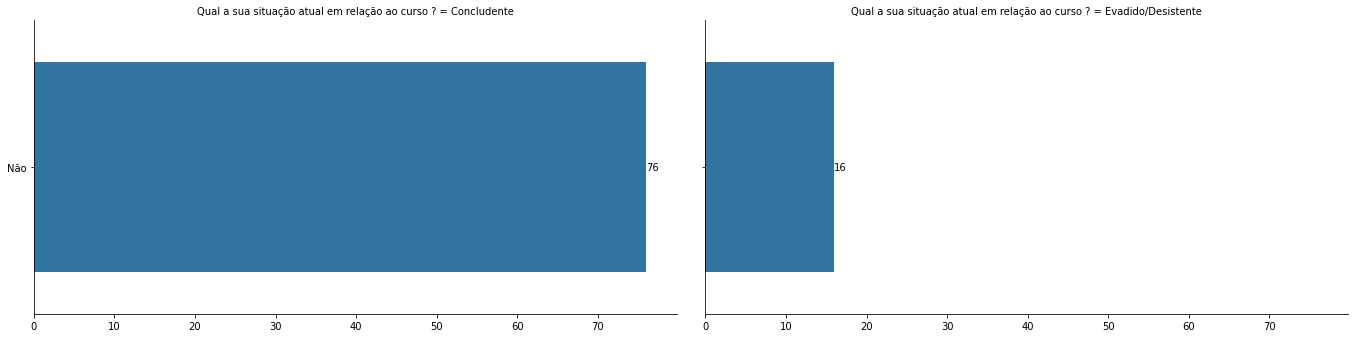

In [15]:
g = sns.catplot(y=base.iloc[:,23].name, col=base.iloc[:,1].name, data=base, kind="count",col_wrap=2)
g.fig.set_size_inches(20,5)
for ax in g.axes.ravel():
    for c in ax.containers:
        labels = [f'{(v.get_width()):.0f}' for v in c]
        ax.bar_label(c, labels=labels)
    ax.margins(y=0.2)
g.set_axis_labels("", "")    
## Salvando figura
g.savefig('aproveitamento entre concludentes e evasores.png',bbox_inches='tight')
print('BioTECH - Filhos')
plt.show()

## Perguntas sobre fatores individuas, internos à instituição e externos à instituição [Quando estava na universidade, você  trabalhava?]

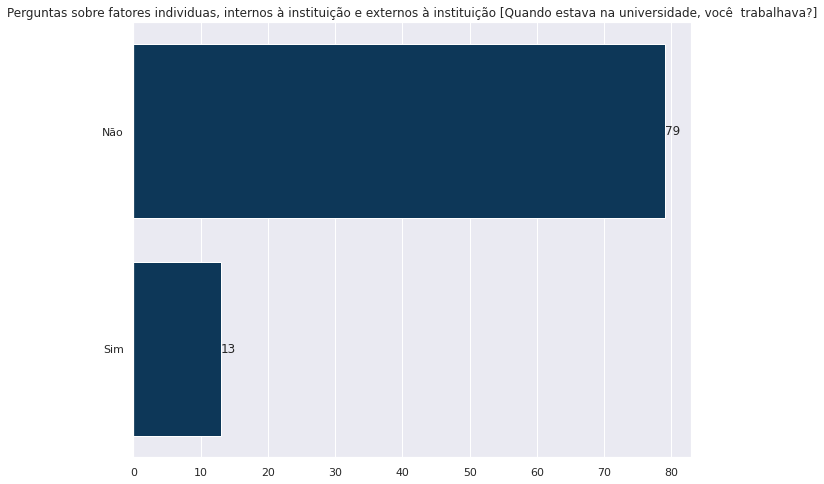

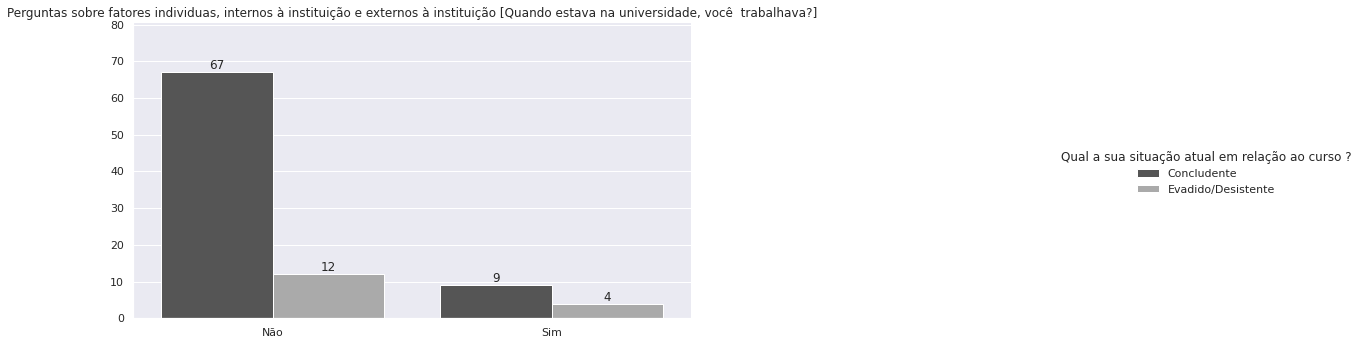

In [ ]:
coluna = 24
ax = sns.countplot(y=base.iloc[:,coluna], data=base, order = base.iloc[:,coluna].value_counts().index, color="#003865")
valores = base.iloc[:,coluna].value_counts().values
ax.bar_label(container=ax.containers[0], labels=valores)
plt.title(base.iloc[:,coluna].name)
plt.xlabel('')
plt.ylabel('')
plt.show()


g = sns.catplot(x=base.iloc[:,coluna].name ,hue=base.iloc[:,1].name, data=base, kind="count", palette='gist_gray')
g.fig.set_size_inches(20,5)
for ax in g.axes.ravel():
    for c in ax.containers:
        labels = [f'{(v.get_height()):.0f}' for v in c]
        ax.bar_label(c, labels=labels)
    ax.margins(y=0.2)
g.set_axis_labels("", "")      
plt.title(base.iloc[:,coluna].name)
plt.show()

Ao perguntar aos alunos se trabalhava enquanto estava na universidade 85% (79) dos alunos não trabalham e apenas 15% (13) dos alunos já trabalhava durante a vida acadêmica na universidade. 75% da evasão nesse contexto são dos alunos que não trabalham e apenas 25% são dos alunos que trabalham, isso só reforça que o perfil dos casados tem mais propensão a conclusão da vida acadêmica.

## Perguntas sobre fatores individuas, internos à instituição e externos à instituição [Você foi contemplado alguma bolsa durante o período que esteve no curso?]

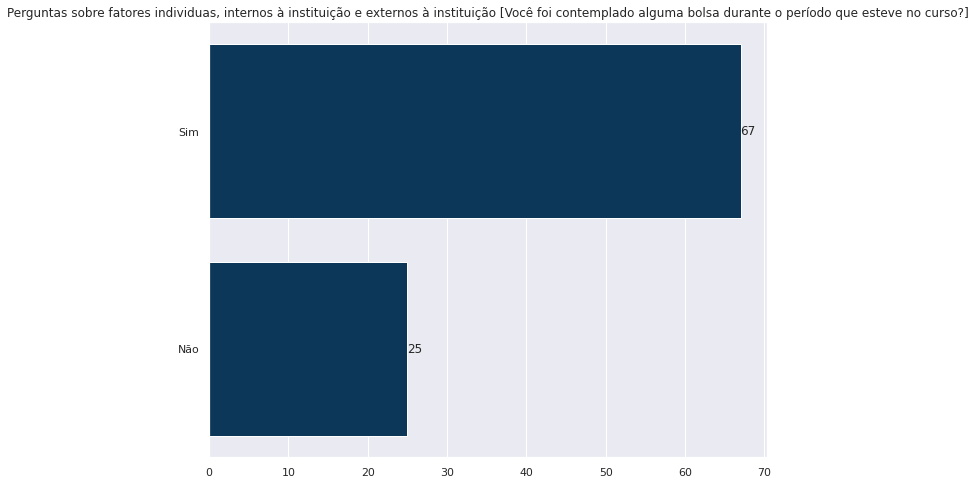

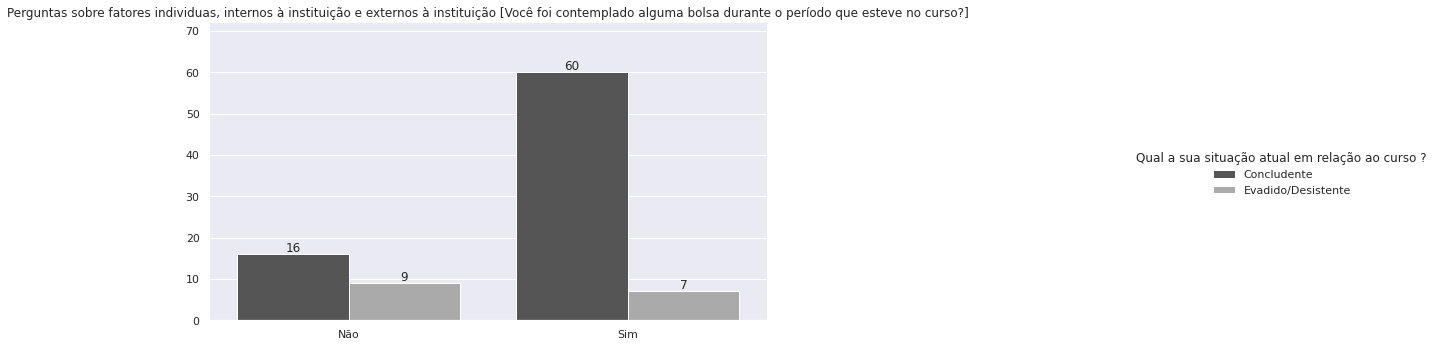

In [ ]:
coluna = 25
ax = sns.countplot(y=base.iloc[:,coluna], data=base, order = base.iloc[:,coluna].value_counts().index, color="#003865")
valores = base.iloc[:,coluna].value_counts().values
ax.bar_label(container=ax.containers[0], labels=valores)
plt.title(base.iloc[:,coluna].name)
plt.xlabel('')
plt.ylabel('')
## Salvando figura
fig = ax.get_figure()
fig.savefig('15.1 - bolsistas - Cursos Biotecnologia e Engenharia ambiental.png',bbox_inches='tight')
plt.show()


g = sns.catplot(x=base.iloc[:,coluna].name ,hue=base.iloc[:,1].name, data=base, kind="count", palette='gist_gray')
g.fig.set_size_inches(20,5)
for ax in g.axes.ravel():
    for c in ax.containers:
        labels = [f'{(v.get_height()):.0f}' for v in c]
        ax.bar_label(c, labels=labels)
    ax.margins(y=0.2)
g.set_axis_labels("", "")      
plt.title(base.iloc[:,coluna].name)
plt.show()

Se tratando de bolsas 72% (67) dos alunos tiveram oportunidade de ter acesso a bolsa durante a vida acadêmica na universidade e apenas 28% (25) dos estudantes não. Fator interessante já que a proporção de bolsas normalmente é bem menor para o volume de alunos e na maioria dos casos esses dados seria invertido. Ao analisar a evasão desse grupo é possível perceber que mesmo com ou sem a bolsa não foi fator decisivo para se manter na instituição.

BioTECH - Bolsa


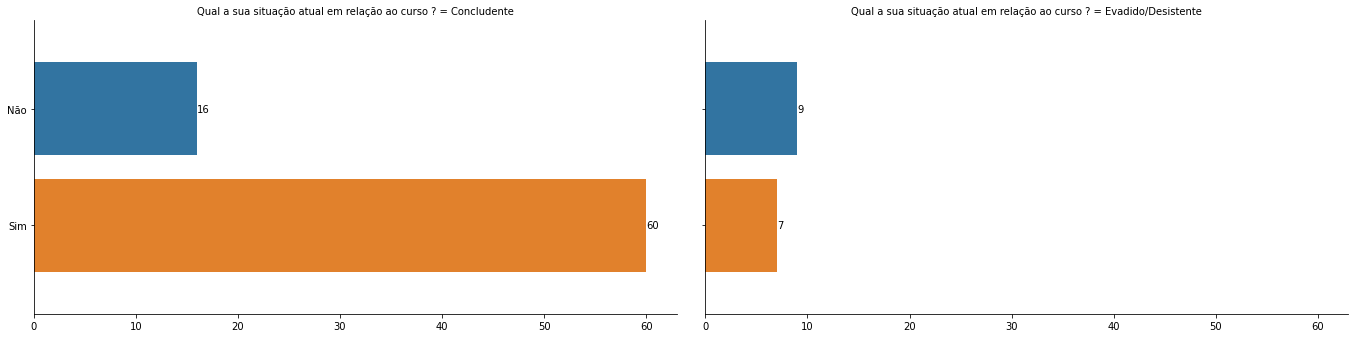

In [11]:
g = sns.catplot(y=base.iloc[:,25].name, col=base.iloc[:,1].name, data=base, kind="count",col_wrap=2)
g.fig.set_size_inches(20,5)
for ax in g.axes.ravel():
    for c in ax.containers:
        labels = [f'{(v.get_width()):.0f}' for v in c]
        ax.bar_label(c, labels=labels)
    ax.margins(y=0.2)
g.set_axis_labels("", "")    
## Salvando figura
g.savefig('aproveitamento entre concludentes e evasores.png',bbox_inches='tight')
print('BioTECH - Bolsa')
plt.show()

## Perguntas sobre fatores individuas, internos à instituição e externos à instituição [Você considera que, durante o período que esteve no curso, teve o devido acompanhamento da universidade? Exemplo: PROAE ou Coordenação do curso.]

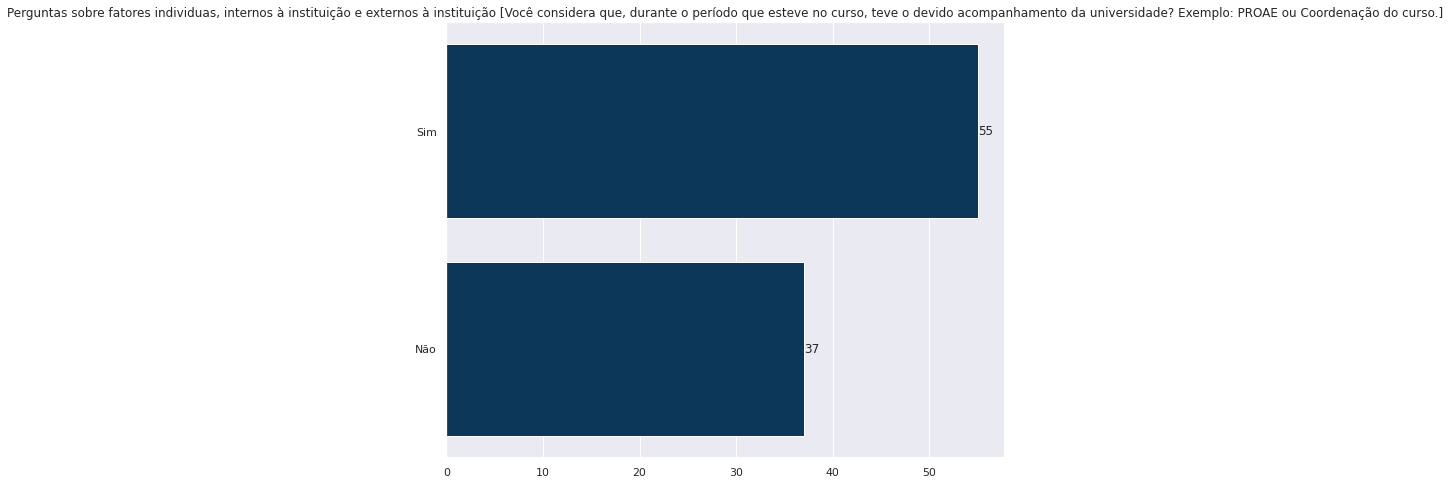

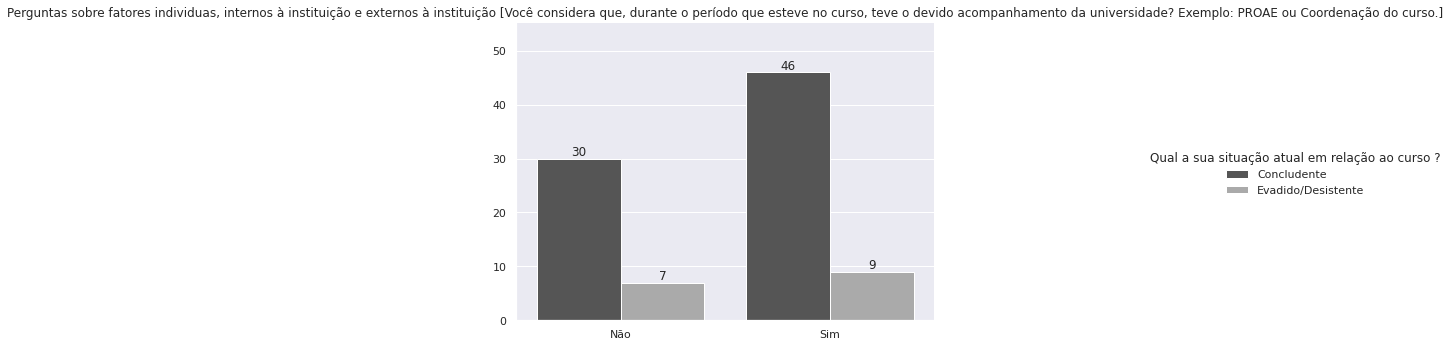

In [ ]:
coluna = 26
ax = sns.countplot(y=base.iloc[:,coluna], data=base, order = base.iloc[:,coluna].value_counts().index, color="#003865")
valores = base.iloc[:,coluna].value_counts().values
ax.bar_label(container=ax.containers[0], labels=valores)
plt.title(base.iloc[:,coluna].name)
plt.xlabel('')
plt.ylabel('')
plt.show()


g = sns.catplot(x=base.iloc[:,coluna].name ,hue=base.iloc[:,1].name, data=base, kind="count", palette='gist_gray')
g.fig.set_size_inches(15,5)
for ax in g.axes.ravel():
    for c in ax.containers:
        labels = [f'{(v.get_height()):.0f}' for v in c]
        ax.bar_label(c, labels=labels)
    ax.margins(y=0.2)
g.set_axis_labels("", "")      
plt.title(base.iloc[:,coluna].name)
plt.show()

Acompanhamento na universidade é um ponto que pode gerar polêmica ao abordar esse assunto, e depende bastante do ponto de vista analisado, mas em regra geral segundo os alunos 60% (55) informaram que tiveram o devido acompanhamento durante sua jornada acadêmica e aproximadamente 40% (37) dos alunos declararam que não. Ao tratar da evasão 56% (9) dos alunos que mesmo informando que receberam o acompanhamento evadiram-se, neste caso, será que a universidade está deixando de acompanhar algum ponto importante?

## Perguntas sobre fatores individuas, internos à instituição e externos à instituição [Você considera que a grade curricular do seu curso é adequada ao que se exige no mercado de trabalho?]

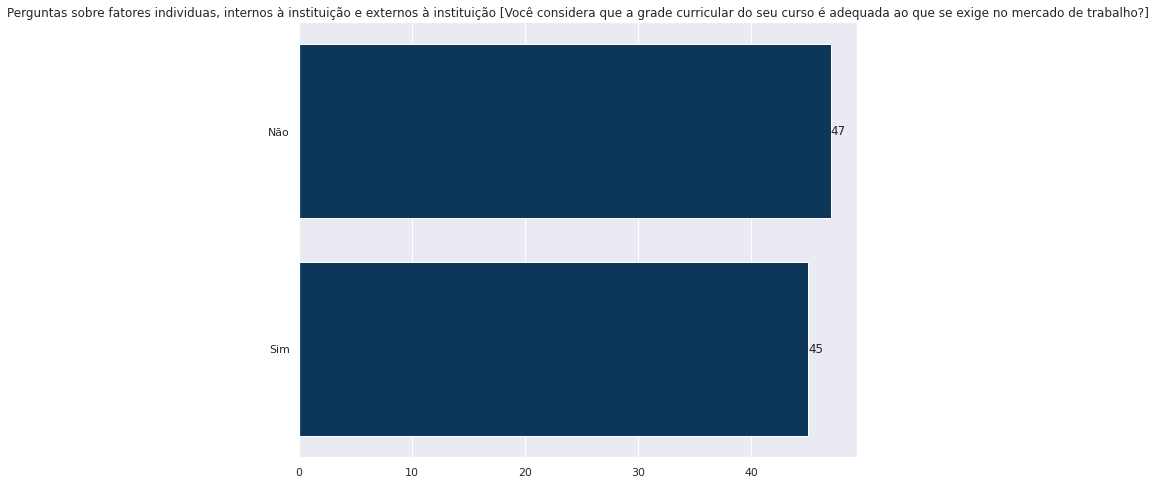

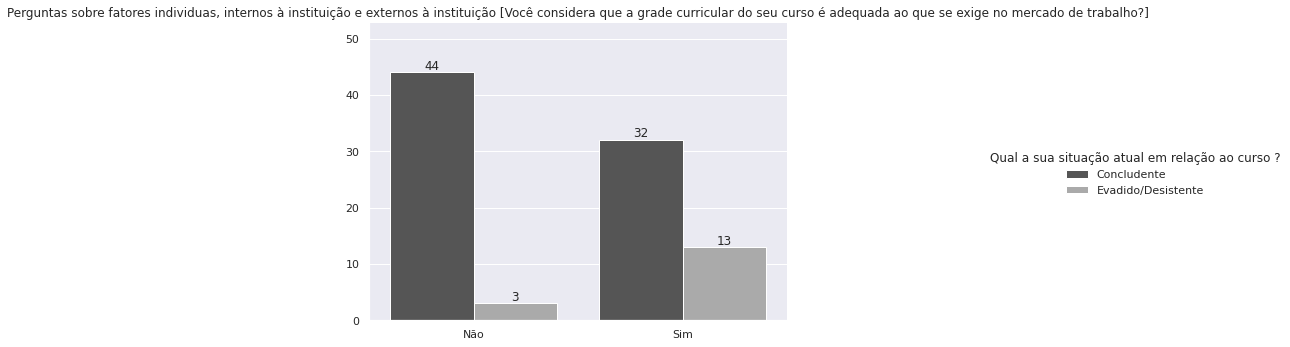

In [ ]:
coluna = 27
ax = sns.countplot(y=base.iloc[:,coluna], data=base, order = base.iloc[:,coluna].value_counts().index, color="#003865")
valores = base.iloc[:,coluna].value_counts().values
ax.bar_label(container=ax.containers[0], labels=valores)
plt.title(base.iloc[:,coluna].name)
plt.xlabel('')
plt.ylabel('')
plt.show()


g = sns.catplot(x=base.iloc[:,coluna].name ,hue=base.iloc[:,1].name, data=base, kind="count", palette='gist_gray')
g.fig.set_size_inches(15,5)
for ax in g.axes.ravel():
    for c in ax.containers:
        labels = [f'{(v.get_height()):.0f}' for v in c]
        ax.bar_label(c, labels=labels)
    ax.margins(y=0.2)
g.set_axis_labels("", "")      
plt.title(base.iloc[:,coluna].name)
plt.show()

Preparação para o mercado, é comprovado que as universidades de um modo geral preparam seu alunos para atuarem em um universo mais acadêmico do que mesmo do profissinal, porém, existe uma certa divisão desse entendimento dos alunos do conjunto em estudo, pois, 51% (47)concorda com a citação acima, já os demais declaram que a universidade prepara sim os seus estudantes para o mercado, mas um certo contraste existe ao compreender essas informação ao analisar a evasão, já que 81% (13) dos evadidos são os mesmos que afirmaram que a universidade prepara para o mercado.

## Perguntas sobre fatores individuas, internos à instituição e externos à instituição [Em relação à cadeia de pré-requisitos das disciplinas do curso, você considera adequada?]

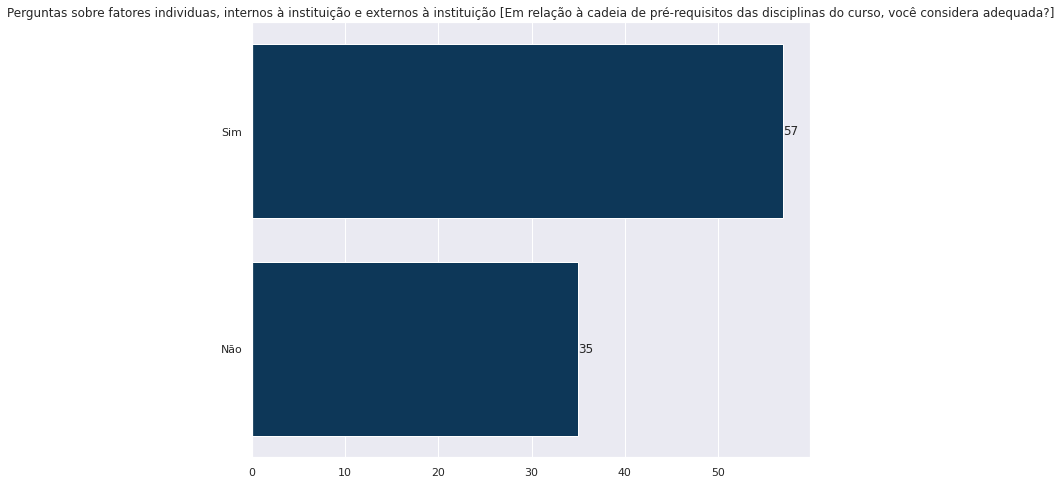

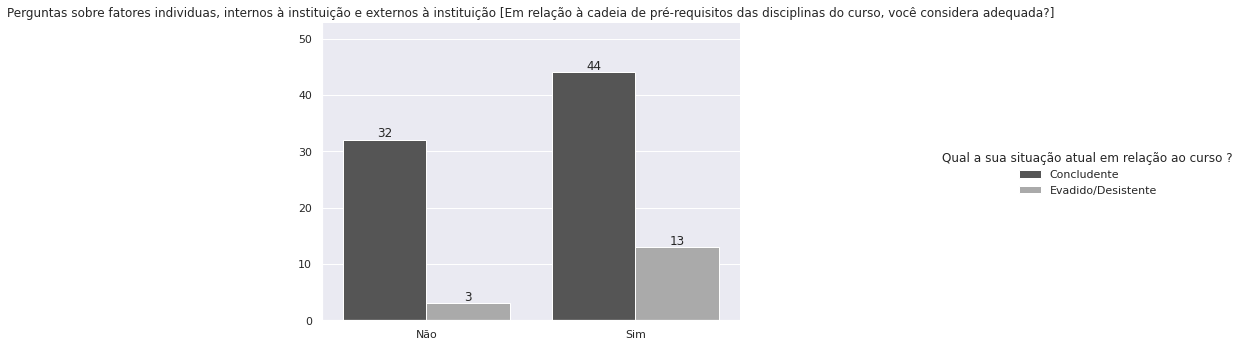

In [ ]:
coluna = 28
ax = sns.countplot(y=base.iloc[:,coluna], data=base, order = base.iloc[:,coluna].value_counts().index, color="#003865")
valores = base.iloc[:,coluna].value_counts().values
ax.bar_label(container=ax.containers[0], labels=valores)
plt.title(base.iloc[:,coluna].name)
plt.xlabel('')
plt.ylabel('')
## Salvando figura
fig = ax.get_figure()
fig.savefig('11.1 - disciplinas adequadas - Cursos Biotecnologia e Engenharia ambiental.png',bbox_inches='tight')
plt.show()


g = sns.catplot(x=base.iloc[:,coluna].name ,hue=base.iloc[:,1].name, data=base, kind="count", palette='gist_gray')
g.fig.set_size_inches(15,5)
for ax in g.axes.ravel():
    for c in ax.containers:
        labels = [f'{(v.get_height()):.0f}' for v in c]
        ax.bar_label(c, labels=labels)
    ax.margins(y=0.2)
g.set_axis_labels("", "")      
plt.title(base.iloc[:,coluna].name)
plt.show()

Esse dado corrobora com a pergunta anterior, reforçando cada vez mais que os alunos que consideram adequada são os que mais evadem com aproximadamente 81% (13).

BioTECH - Pré-requisitos


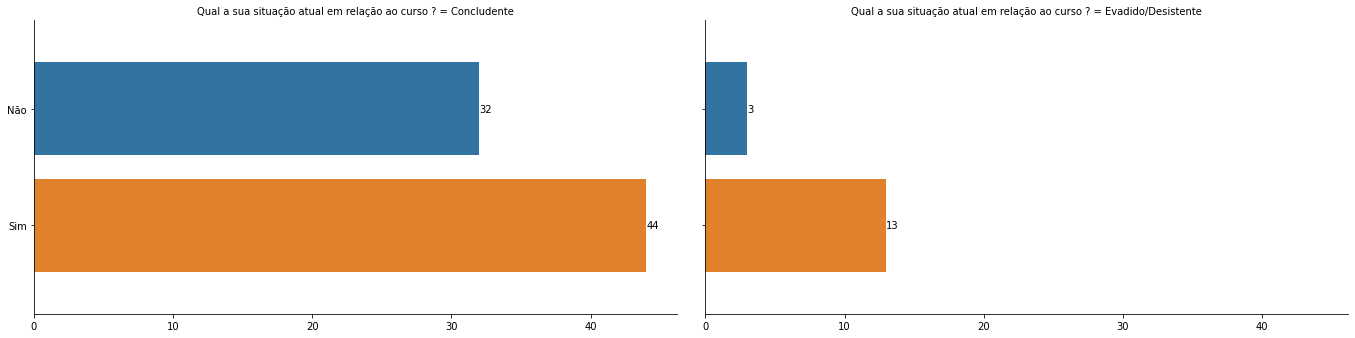

In [13]:
g = sns.catplot(y=base.iloc[:,28].name, col=base.iloc[:,1].name, data=base, kind="count",col_wrap=2)
g.fig.set_size_inches(20,5)
for ax in g.axes.ravel():
    for c in ax.containers:
        labels = [f'{(v.get_width()):.0f}' for v in c]
        ax.bar_label(c, labels=labels)
    ax.margins(y=0.2)
g.set_axis_labels("", "")    
## Salvando figura
g.savefig('aproveitamento entre concludentes e evasores.png',bbox_inches='tight')
print('BioTECH - Pré-requisitos')
plt.show()

## Perguntas sobre fatores individuas, internos à instituição e externos à instituição [Em relação aos critérios de avaliação do desempenho do aluno, você considera adequado?]

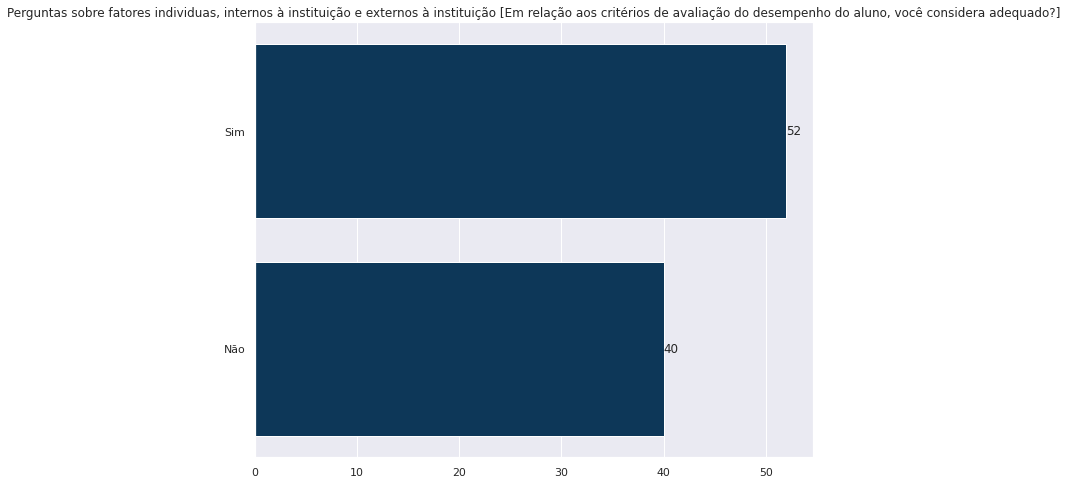

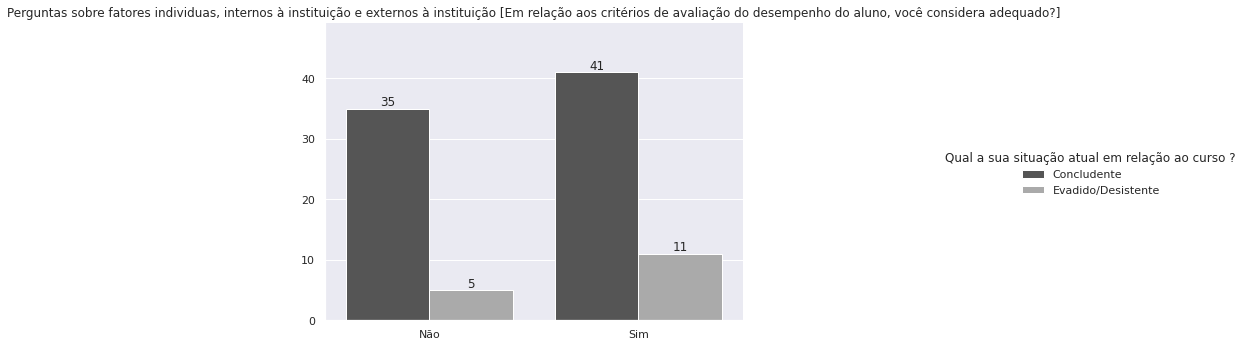

In [ ]:
coluna = 29
ax = sns.countplot(y=base.iloc[:,coluna], data=base, order = base.iloc[:,coluna].value_counts().index, color="#003865")
valores = base.iloc[:,coluna].value_counts().values
ax.bar_label(container=ax.containers[0], labels=valores)
plt.title(base.iloc[:,coluna].name)
plt.xlabel('')
plt.ylabel('')
plt.show()


g = sns.catplot(x=base.iloc[:,coluna].name ,hue=base.iloc[:,1].name, data=base, kind="count", palette='gist_gray')
g.fig.set_size_inches(15,5)
for ax in g.axes.ravel():
    for c in ax.containers:
        labels = [f'{(v.get_height()):.0f}' for v in c]
        ax.bar_label(c, labels=labels)
    ax.margins(y=0.2)
g.set_axis_labels("", "")      
plt.title(base.iloc[:,coluna].name)
plt.show()

Critérios de avaliação para muitos é algo a ser discutido, já para outros algo a ser seguido. Neste contexto 56% (52) dos alunos consideram adequado, já os 44% (40) dos alunos não consideram. Vale destacar que 69% (11) dos evadidos são os alunos que consideram adequadas as regras de avaliação, pode ser algo a ser questionado já que eles podem não ter compreendido o detalhe de cada critério, existe um estudo que declara o nível de entendimento dos alunos recém chegados na universidade, e para identificar se esses alunos participam desse cenário seria importante realizar uma pesquisa mais profunda com esse grupo. 

## Perguntas sobre fatores individuas, internos à instituição e externos à instituição [Em relação à infraestrutura da instituição como laboratórios, bibliotecas, equipamentos de informática e etc, você considera adequada?]

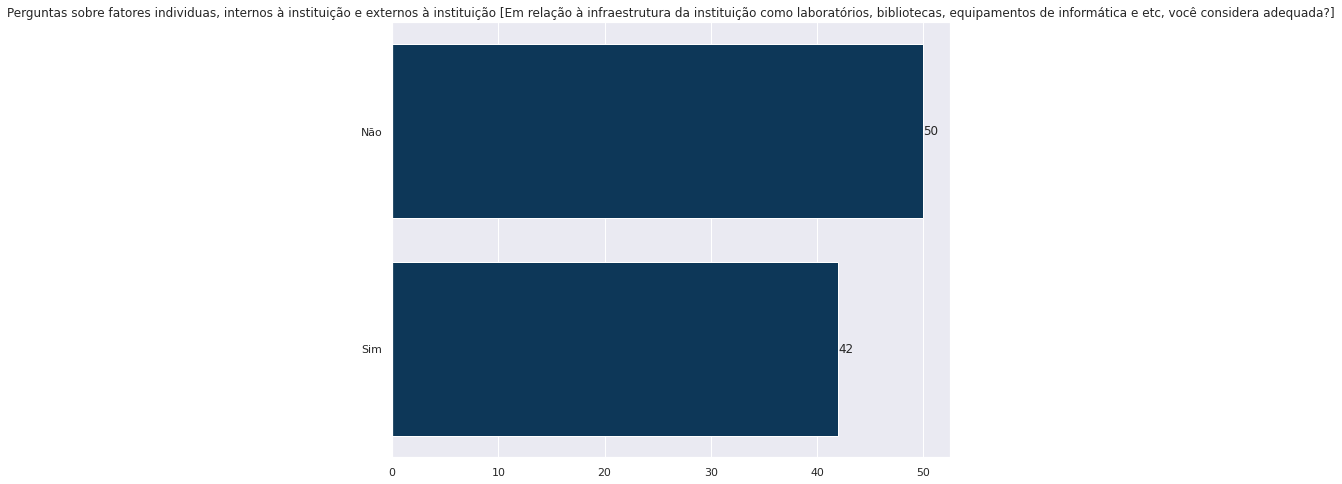

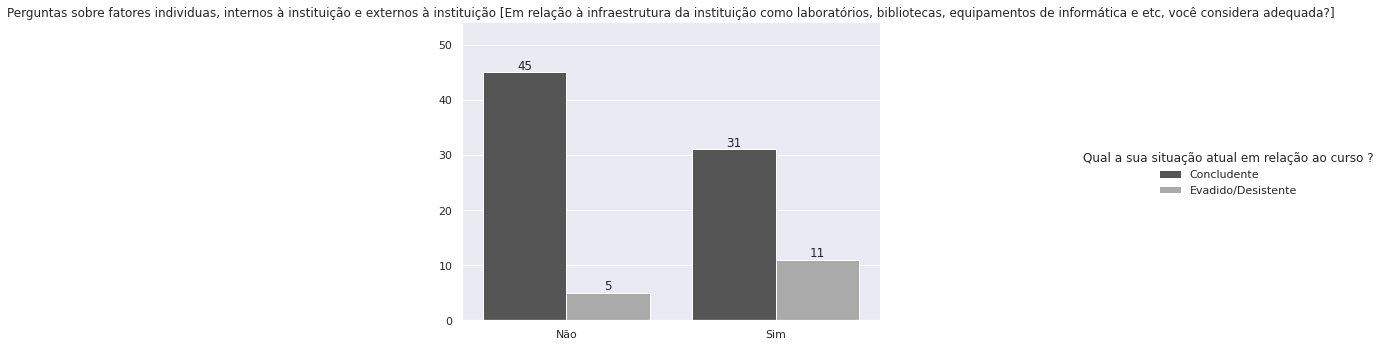

In [ ]:
coluna = 30
ax = sns.countplot(y=base.iloc[:,coluna], data=base, order = base.iloc[:,coluna].value_counts().index, color="#003865")
valores = base.iloc[:,coluna].value_counts().values
ax.bar_label(container=ax.containers[0], labels=valores)
plt.title(base.iloc[:,coluna].name)
plt.xlabel('')
plt.ylabel('')
plt.show()


g = sns.catplot(x=base.iloc[:,coluna].name ,hue=base.iloc[:,1].name, data=base, kind="count", palette='gist_gray')
g.fig.set_size_inches(15,5)
for ax in g.axes.ravel():
    for c in ax.containers:
        labels = [f'{(v.get_height()):.0f}' for v in c]
        ax.bar_label(c, labels=labels)
    ax.margins(y=0.2)
g.set_axis_labels("", "")      
plt.title(base.iloc[:,coluna].name)
plt.show()

Os dados de distribuição são os mesmos da pergunta anterior.

## Perguntas sobre fatores individuas, internos à instituição e externos à instituição [Em relação aos professores, você considera que os mesmos apresentam deficiências pedagógicas, desinteresse ou outros problemas?]



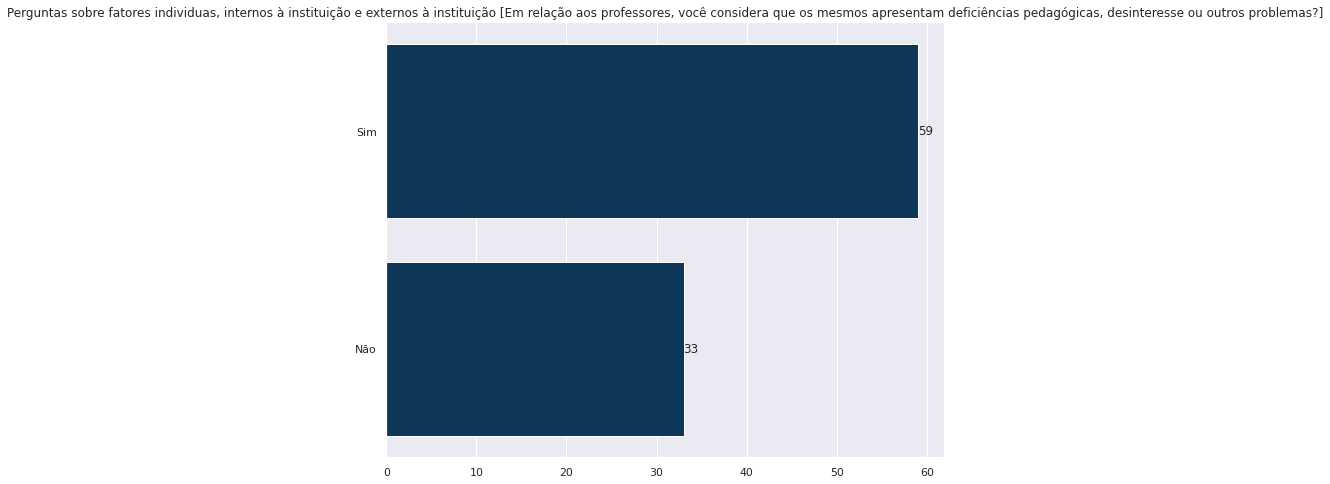

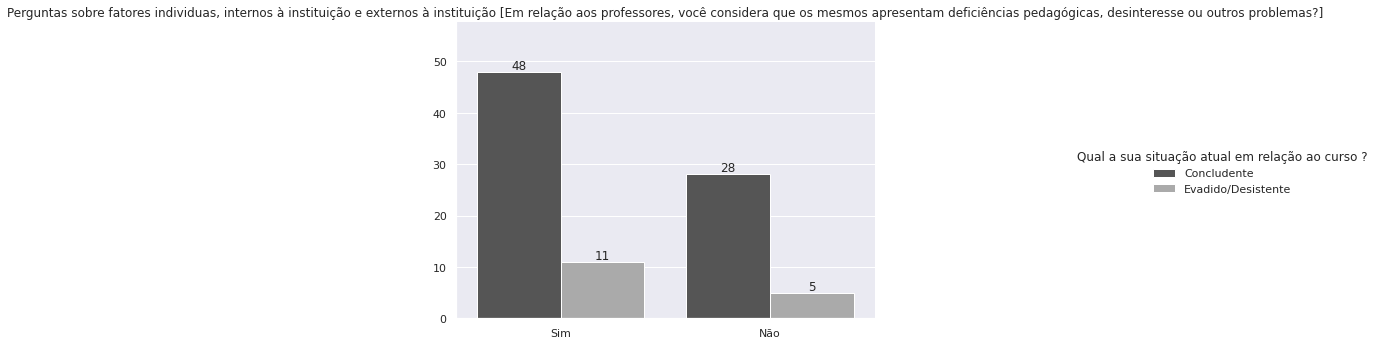

In [ ]:
coluna = 31
ax = sns.countplot(y=base.iloc[:,coluna], data=base, order = base.iloc[:,coluna].value_counts().index, color="#003865")
valores = base.iloc[:,coluna].value_counts().values
ax.bar_label(container=ax.containers[0], labels=valores)
plt.title(base.iloc[:,coluna].name)
plt.xlabel('')
plt.ylabel('')
plt.show()


g = sns.catplot(x=base.iloc[:,coluna].name ,hue=base.iloc[:,1].name, data=base, kind="count", palette='gist_gray')
g.fig.set_size_inches(15,5)
for ax in g.axes.ravel():
    for c in ax.containers:
        labels = [f'{(v.get_height()):.0f}' for v in c]
        ax.bar_label(c, labels=labels)
    ax.margins(y=0.2)
g.set_axis_labels("", "")      
plt.title(base.iloc[:,coluna].name)
plt.show()

Em relação aos professores, alguns alunos consideram que os mesmos apresentam deficiências pedagógicas, desinteresse ou outros problemas que podem ser associado a falta de vontade de lecionar, desse conjunto de alunos 64% (59) afirmaram que sim, existem professores com o perfil supracitado e apenas 36% (33) declaram que não. Fato interessante é que do conjunto dos alunos que afirmaram sim 69% (11) são evasores isso, corrobora com a possível falta de planejamento, deficiência pedagógica, desinteresse ou outros problemas, tudo isso, associado aos déficits dos alunos acarretam em grande números de evasões. 

## Dos alunos que consideram os professores com deficiências pedagógicas qual é a sua origem?

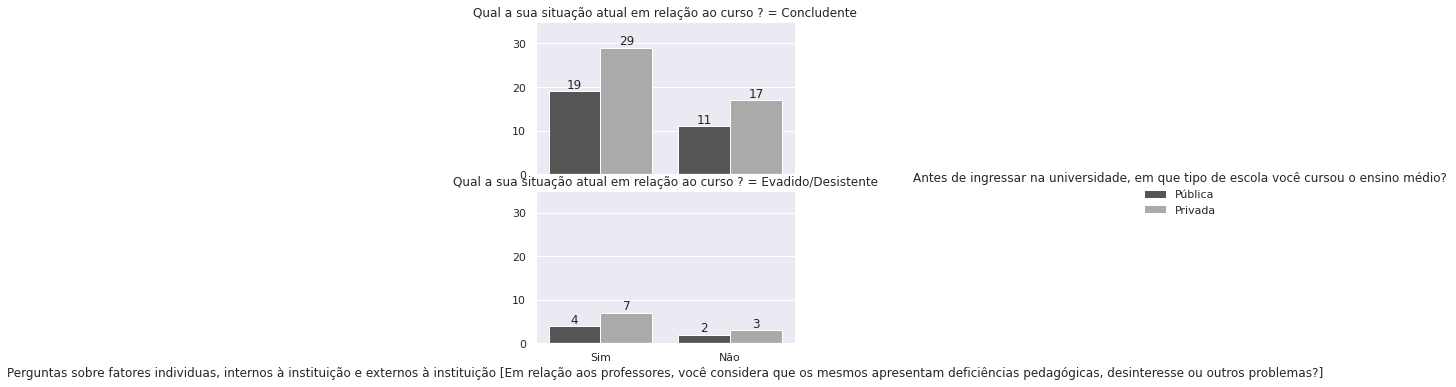

In [ ]:
coluna = 31
g = sns.catplot(x=base.iloc[:,coluna].name ,hue=base.iloc[:,12].name,col=base.iloc[:,1].name, data=base, kind="count", palette='gist_gray', col_wrap=1)
g.fig.set_size_inches(15,5)
for ax in g.axes.ravel():
    for c in ax.containers:
        labels = [f'{(v.get_height()):.0f}' for v in c]
        ax.bar_label(c, labels=labels)
    ax.margins(y=0.2)
g.set_axis_labels(base.iloc[:,coluna].name , "")      
plt.show()

In [ ]:
base.iloc[:,coluna].name

'Perguntas sobre fatores individuas, internos à instituição e externos à instituição [Em relação aos professores, você considera que os mesmos apresentam deficiências pedagógicas, desinteresse ou outros problemas?]'

## Perguntas sobre fatores individuas, internos à instituição e externos à instituição [Você considera que as carreiras relacionadas ao curso são socialmente reconhecidas?]

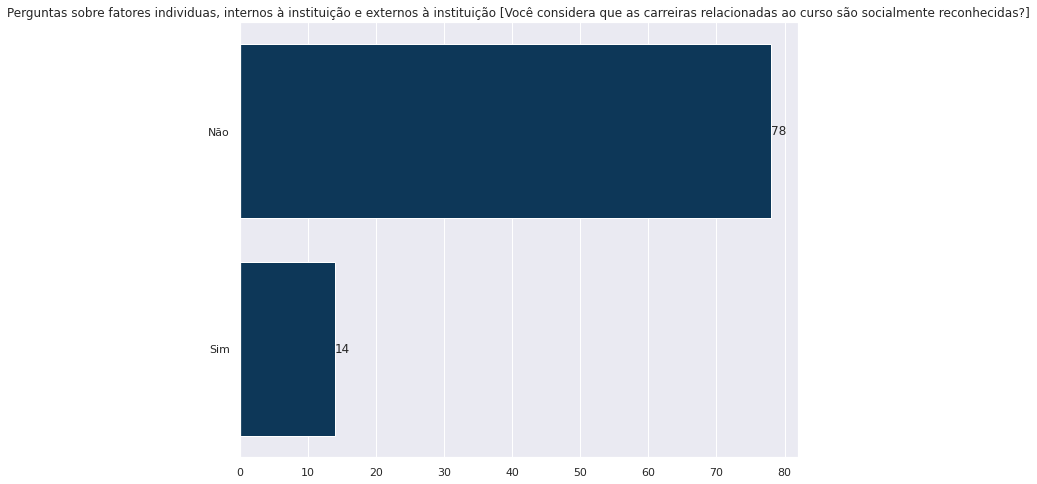

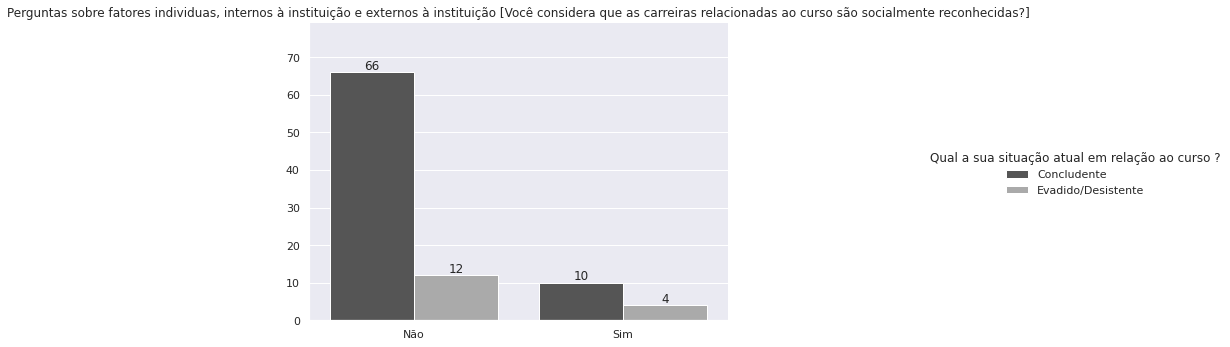

In [ ]:
coluna = 32
ax = sns.countplot(y=base.iloc[:,coluna], data=base, order = base.iloc[:,coluna].value_counts().index, color="#003865")
valores = base.iloc[:,coluna].value_counts().values
ax.bar_label(container=ax.containers[0], labels=valores)
plt.title(base.iloc[:,coluna].name)
plt.xlabel('')
plt.ylabel('')
plt.show()


g = sns.catplot(x=base.iloc[:,coluna].name ,hue=base.iloc[:,1].name, data=base, kind="count", palette='gist_gray')
g.fig.set_size_inches(15,5)
for ax in g.axes.ravel():
    for c in ax.containers:
        labels = [f'{(v.get_height()):.0f}' for v in c]
        ax.bar_label(c, labels=labels)
    ax.margins(y=0.2)
g.set_axis_labels("", "")      
plt.title(base.iloc[:,coluna].name)
plt.show()

Entre as perguntas realizadas com os alunos é possível destacar se os alunos consideram seu curso socialmente reconhecido, e foi possível identificar que 84% (78) alunos não consideram seu curso socialmente reconhecido, restando apenas 16% (14) que confirma o contrário. Já sobre a evasão 75% (12) são dos que não consideram o curso socialmente reconhecido, sobrando apenas 25% (4) dos evadidos que consideram o curso socialmente reconhecido.

## Perguntas sobre fatores individuas, internos à instituição e externos à instituição [Em relação ao mercado, você considera que o profissional formado no curso que você escolheu, é pago adequadamente?]

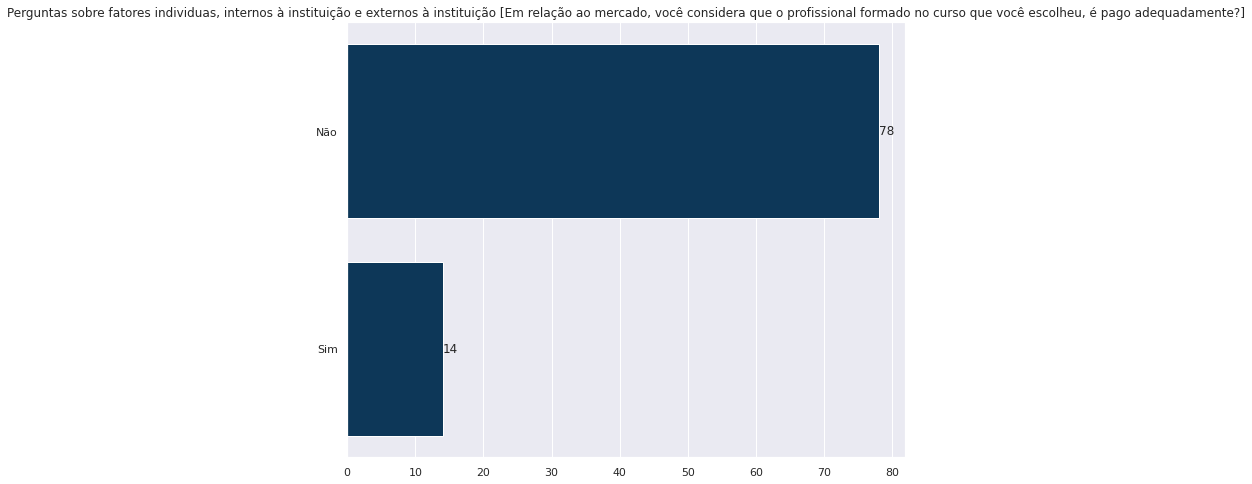

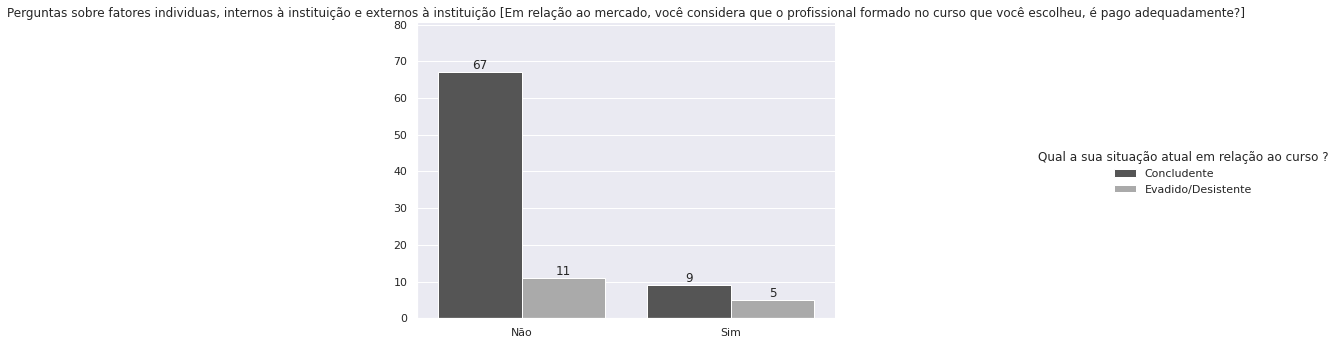

In [ ]:
coluna = 33
ax = sns.countplot(y=base.iloc[:,coluna], data=base, order = base.iloc[:,coluna].value_counts().index, color="#003865")
valores = base.iloc[:,coluna].value_counts().values
ax.bar_label(container=ax.containers[0], labels=valores)
plt.title(base.iloc[:,coluna].name)
plt.xlabel('')
plt.ylabel('')
plt.show()


g = sns.catplot(x=base.iloc[:,coluna].name ,hue=base.iloc[:,1].name, data=base, kind="count", palette='gist_gray')
g.fig.set_size_inches(15,5)
for ax in g.axes.ravel():
    for c in ax.containers:
        labels = [f'{(v.get_height()):.0f}' for v in c]
        ax.bar_label(c, labels=labels)
    ax.margins(y=0.2)
g.set_axis_labels("", "")      
plt.title(base.iloc[:,coluna].name)
plt.show()

Os dados estatísticos são semelhantes a pergunta anterior

## Perguntas sobre fatores individuas, internos à instituição e externos à instituição [Durante o período em que você estava na universidade, seus pais eram casados?]

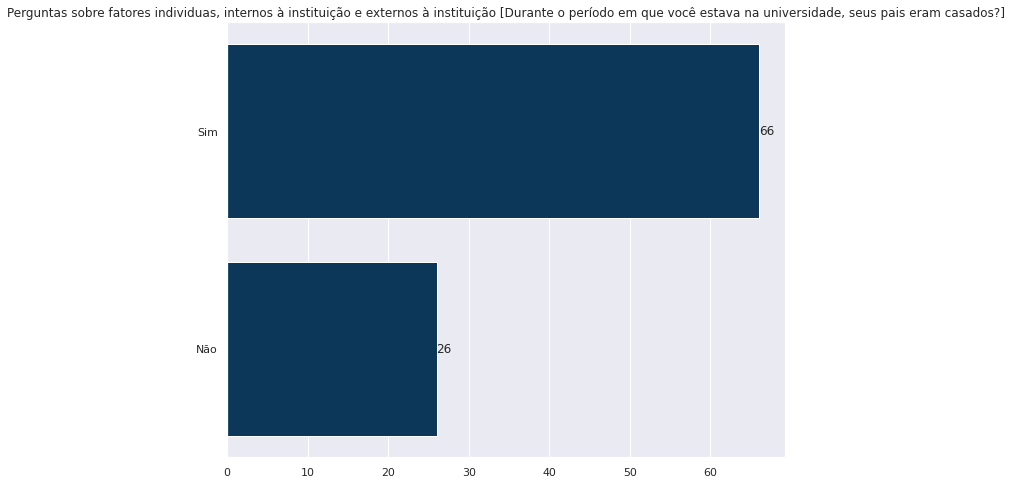

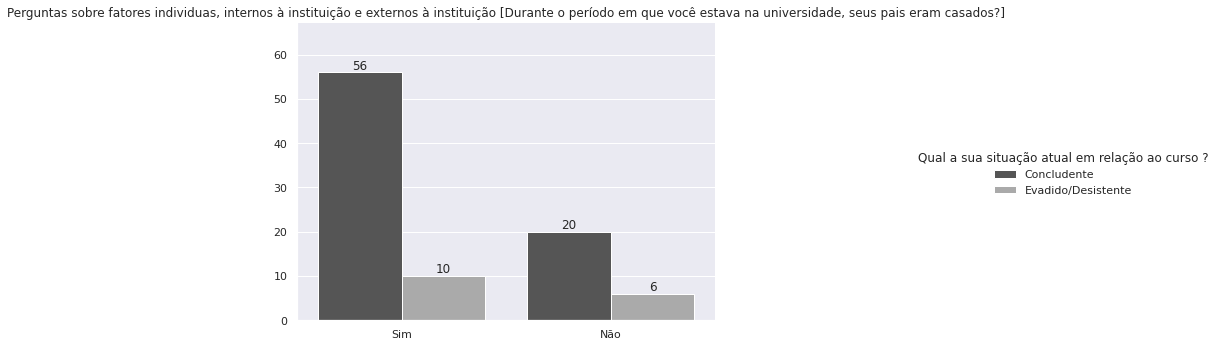

In [ ]:
coluna = 34
ax = sns.countplot(y=base.iloc[:,coluna], data=base, order = base.iloc[:,coluna].value_counts().index, color="#003865")
valores = base.iloc[:,coluna].value_counts().values
ax.bar_label(container=ax.containers[0], labels=valores)
plt.title(base.iloc[:,coluna].name)
plt.xlabel('')
plt.ylabel('')
plt.show()


g = sns.catplot(x=base.iloc[:,coluna].name ,hue=base.iloc[:,1].name, data=base, kind="count", palette='gist_gray')
g.fig.set_size_inches(15,5)
for ax in g.axes.ravel():
    for c in ax.containers:
        labels = [f'{(v.get_height()):.0f}' for v in c]
        ax.bar_label(c, labels=labels)
    ax.margins(y=0.2)
g.set_axis_labels("", "")      
plt.title(base.iloc[:,coluna].name)
plt.show()

Sobre o estado civil dos pais dos estudantes durante a vida acadêmica é possível mensurar que 71% (66) dos alunos possuem pais casados e apenas 29% (26) dos alunos não, porém, ao análisar a evasão 62% são oriundos dos estudantes que possuem pais casados e apenas 38% (6) dos alunos não. Existem fatores familiares que podem influenciar na evasão dos alunos, não pode-se concluir neste caso.

## Ao ingressar na universidade, qual era a renda mensal da sua família?

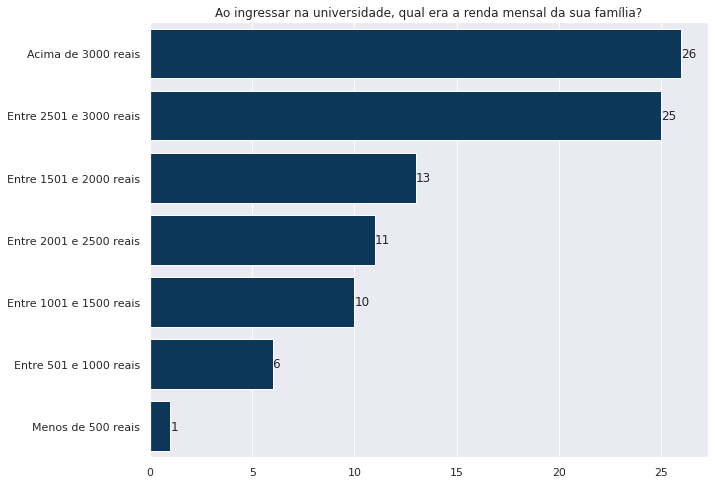

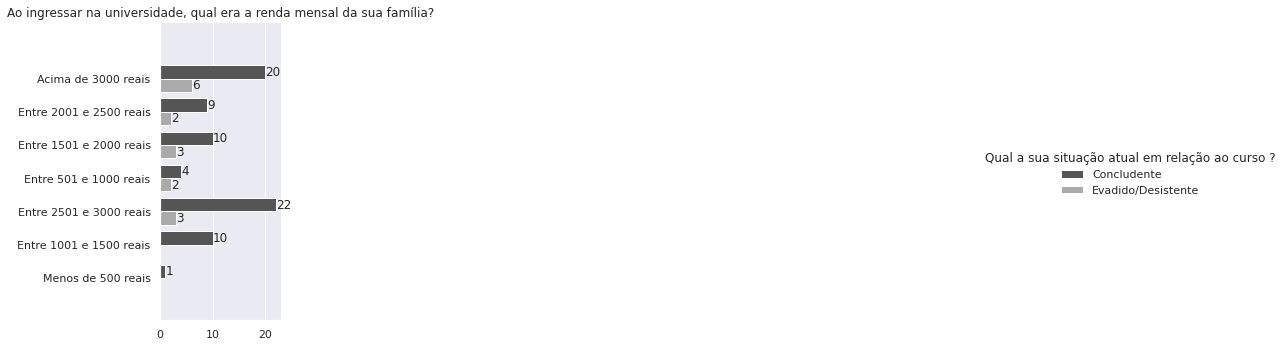

In [ ]:
coluna = 35
ax = sns.countplot(y=base.iloc[:,coluna], data=base, order = base.iloc[:,coluna].value_counts().index, color="#003865")
valores = base.iloc[:,coluna].value_counts().values
ax.bar_label(container=ax.containers[0], labels=valores)
plt.title(base.iloc[:,coluna].name)
plt.xlabel('')
plt.ylabel('')

## Salvando figura
fig = ax.get_figure()
fig.savefig('14.1 - renda da familía - Cursos Biotecnologia e Engenharia ambiental.png',bbox_inches='tight')
plt.show()


g = sns.catplot(y=base.iloc[:,coluna].name ,hue=base.iloc[:,1].name, data=base, kind="count", palette='gist_gray')
g.fig.set_size_inches(30,5)
for ax in g.axes.ravel():
    for c in ax.containers:
        labels = [f'{(v.get_width()):.0f}' for v in c]
        ax.bar_label(c, labels=labels)
    ax.margins(y=0.2)
g.set_axis_labels("", "")      
plt.title(base.iloc[:,coluna].name)
plt.show()

BioTECH


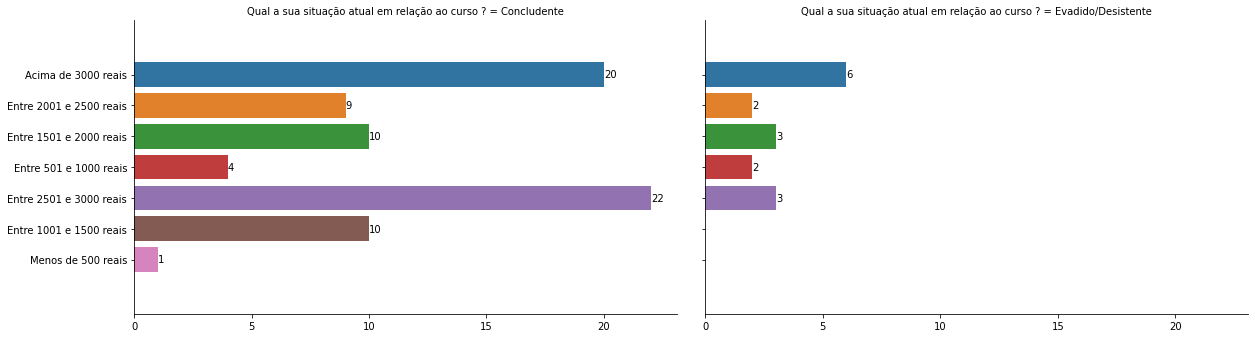

In [6]:
g = sns.catplot(y=base.iloc[:,35].name, col=base.iloc[:,1].name, data=base, kind="count",col_wrap=2)
g.fig.set_size_inches(20,5)
for ax in g.axes.ravel():
    for c in ax.containers:
        labels = [f'{(v.get_width()):.0f}' for v in c]
        ax.bar_label(c, labels=labels)
    ax.margins(y=0.2)
g.set_axis_labels("", "")    
## Salvando figura
g.savefig('aproveitamento entre concludentes e evasores.png',bbox_inches='tight')
print('BioTECH')
plt.show()

Em relação a renda familiar são encontradas 6 categorias, entre elas, iremos destacar as três mais frequêntes que são acima de 3000 reais, entre 2501 e 3000 reais e entre 1501 e 2000 reais, cada um respectivamente com 28%(26), 27%(25) e 14%(13). Discutindo sobre evasão segue a mesma sequência da distribuição da renda sendo os alunos com renda familiar acima de 3 mil com maior volume de evadidos 37%(6). Neste caso, associando os alunos que não consideram o curso relevante e estar em padrão de classe média, favorece em alguns casos a desistência ou evasão do curso.

## Em relação à sua mãe, qual o nível de escolaridade dela?

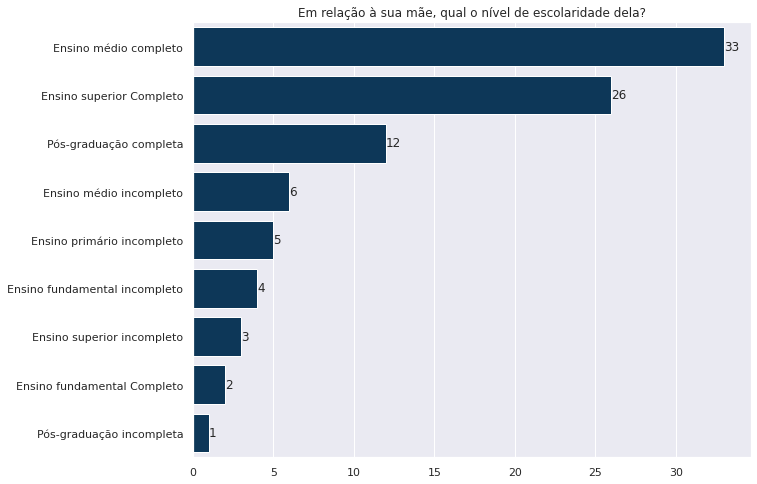

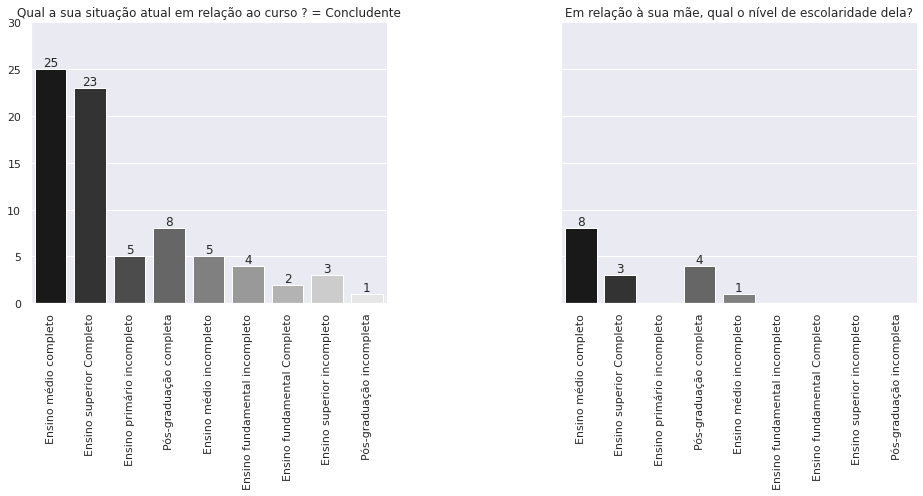

In [ ]:
coluna = 36
ax = sns.countplot(y=base.iloc[:,coluna], data=base, order = base.iloc[:,coluna].value_counts().index, color="#003865")
valores = base.iloc[:,coluna].value_counts().values
ax.bar_label(container=ax.containers[0], labels=valores)
plt.title(base.iloc[:,coluna].name)
plt.xlabel('')
plt.ylabel('')
## Salvando figura
fig = ax.get_figure()
fig.savefig('12.1 - escolaridade mãe - Cursos Biotecnologia e Engenharia ambiental.png',bbox_inches='tight')
plt.show()


g = sns.catplot(x=base.iloc[:,coluna].name ,col=base.iloc[:,1].name, data=base, kind="count", palette='gist_gray')
g.fig.set_size_inches(15,5)
for ax in g.axes.ravel():
    for c in ax.containers:
        labels = [f'{(v.get_height()):.0f}' for v in c]
        ax.bar_label(c, labels=labels)
    ax.margins(y=0.2)
g.set_axis_labels("", "")      
g.set_xticklabels(rotation=90)
plt.title(base.iloc[:,coluna].name)
plt.show()

Em relação ao nível de escolaridade da mãe dos alunos é possível identificar que existem 35% (33) das mães são do concluíram o ensino médio, 28% (26) concluíram o ensino superior e apenas 13% (12) possuem pós-graduação. Em relação à evasão 50% (8)dos evadidos são das mães que concluiram o ensino médio, seguido das mães que possuem pós-graduação com 25%(4).

BioTECH - Escolaridade da mãe


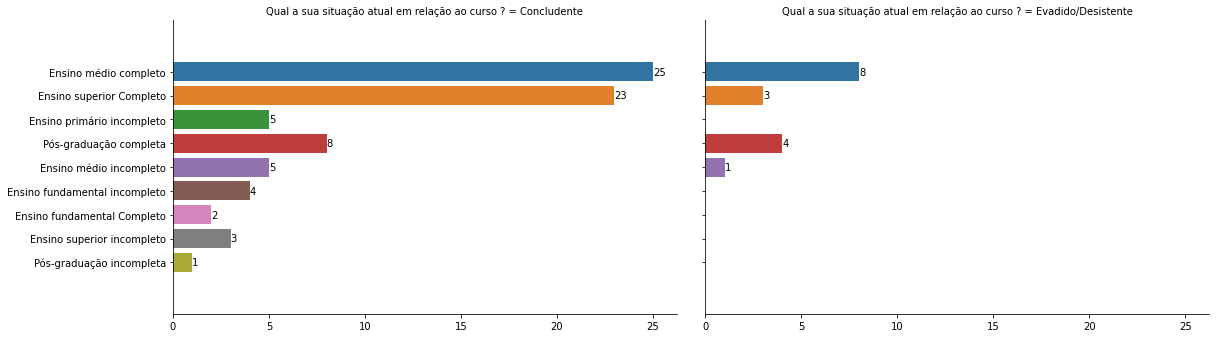

In [8]:
g = sns.catplot(y=base.iloc[:,36].name, col=base.iloc[:,1].name, data=base, kind="count",col_wrap=2)
g.fig.set_size_inches(20,5)
for ax in g.axes.ravel():
    for c in ax.containers:
        labels = [f'{(v.get_width()):.0f}' for v in c]
        ax.bar_label(c, labels=labels)
    ax.margins(y=0.2)
g.set_axis_labels("", "")    
## Salvando figura
g.savefig('aproveitamento entre concludentes e evasores.png',bbox_inches='tight')
print('BioTECH - Escolaridade da mãe')
plt.show()

## Em relação ao seu pai, qual o nível de escolaridade dele?

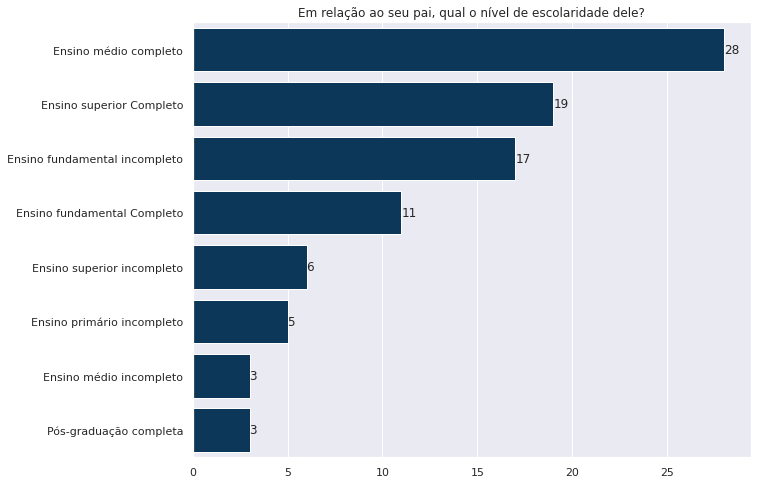

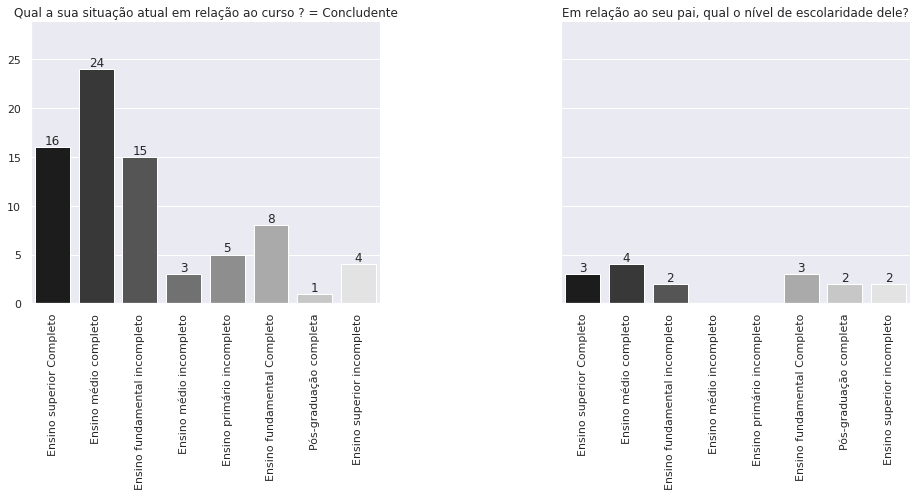

In [ ]:
coluna = 37
ax = sns.countplot(y=base.iloc[:,coluna], data=base, order = base.iloc[:,coluna].value_counts().index, color="#003865")
valores = base.iloc[:,coluna].value_counts().values
ax.bar_label(container=ax.containers[0], labels=valores)
plt.title(base.iloc[:,coluna].name)
plt.xlabel('')
plt.ylabel('')
## Salvando figura
fig = ax.get_figure()
fig.savefig('13.1 - escolaridade pai - Cursos Biotecnologia e Engenharia ambiental.png',bbox_inches='tight')
plt.show()


g = sns.catplot(x=base.iloc[:,coluna].name ,col=base.iloc[:,1].name, data=base, kind="count", palette='gist_gray')
g.fig.set_size_inches(15,5)
for ax in g.axes.ravel():
    for c in ax.containers:
        labels = [f'{(v.get_height()):.0f}' for v in c]
        ax.bar_label(c, labels=labels)
    ax.margins(y=0.2)
g.set_axis_labels("", "")      
g.set_xticklabels(rotation=90)
plt.title(base.iloc[:,coluna].name)
plt.show()

Falando sobre o nivel de escolaridade dos pais, apresenta um número próximo das mães que concluíram o ensino médio com 30% (28), seguido dos pais com nível superior completo com 20%(19) e a diferença surge na 3a categoria que no caso dos pais 18% (17) possuem o ensino fundamental incompleto, sendo possível comparar que a no caso das mães a 3a categoria seria das pós-graduadas, isso pode ser corroborado com os dados dos IBGE já que as pessoas do sexo feminino são as que completam mais os níveis acadêmicos.

BioTECH - Escolaridade do pai


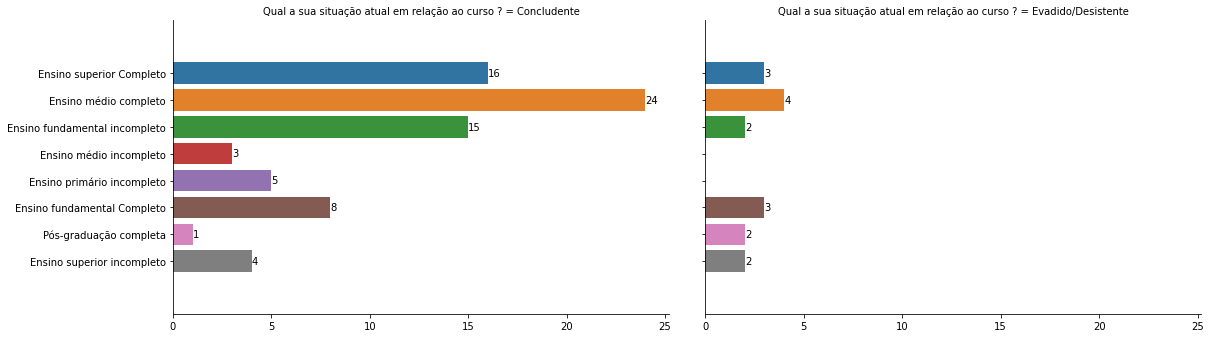

In [7]:
g = sns.catplot(y=base.iloc[:,37].name, col=base.iloc[:,1].name, data=base, kind="count",col_wrap=2)
g.fig.set_size_inches(20,5)
for ax in g.axes.ravel():
    for c in ax.containers:
        labels = [f'{(v.get_width()):.0f}' for v in c]
        ax.bar_label(c, labels=labels)
    ax.margins(y=0.2)
g.set_axis_labels("", "")    
## Salvando figura
g.savefig('aproveitamento entre concludentes e evasores.png',bbox_inches='tight')
print('BioTECH - Escolaridade do pai')
plt.show()

In [ ]:
## convertendo arquivo em html
#%%shell
#jupyter nbconvert --to html ///content/analise_exploratoria_novos_cursos.ipynb

## Selecionando as mesmas características do conjunto anterior

In [ ]:
selecionados = base.loc[:,['Qual a sua situação atual em relação ao curso ?',
                           'Qual a sua Universidade',
                           'Em qual ano e semestre você ingressou no curso? Exemplo 2010.1',
                           'Em qual semestre você concluiu ou desistiu do curso? Exemplo 2015.2',
                           'Com relação ao ingresso no curso, este sempre foi a sua primeira opção de curso?',
                           'Antes de ingressar no curso, você já possuía algum conhecimento prévio na área?',
                           'Caso tenha cursado o ensino fundamental em escola pública, qual foi o tipo de instituição?',
                           'Ao ingressar na universidade você se mudou para morar na mesma cidade do campus que se matriculou?',
                           'A qual raça você se considera pertencer?',
                           'Perguntas sobre fatores individuas, internos à instituição e externos à instituição [Quando estava na universidade, você tinha filhos?]',
                           'Perguntas sobre fatores individuas, internos à instituição e externos à instituição [Em relação à cadeia de pré-requisitos das disciplinas do curso, você considera adequada?]',
                           'Em relação à sua mãe, qual o nível de escolaridade dela?',
                           'Em relação ao seu pai, qual o nível de escolaridade dele?',
                           'Ao ingressar na universidade, qual era a renda mensal da sua família?',
                           'Perguntas sobre fatores individuas, internos à instituição e externos à instituição [Você foi contemplado alguma bolsa durante o período que esteve no curso?]',
                           'Em relação ao seu aproveitamento acadêmico, até o segundo semestre do curso você foi?']]

In [ ]:
selecionados.columns = ['var_0','var_1','var_2','var_3','var_4','var_5','var_9','var_11','var_14','var_16','var_23','var_30','var_31','var_18','var_19','var_20']
selecionados

,var_0,var_1,var_2,var_3,var_4,var_5,var_9,var_11,var_14,var_16,var_23,var_30,var_31,var_18,var_19,var_20
0,Concludente,UFERSA,2016.1,2022.1,Sim,Não,Escola Estadual,Não,Pardo,Não,Não,Ensino médio completo,Ensino superior Completo,Acima de 3000 reais,Não,Reprovado em uma disciplina
1,Concludente,UFERSA,2016.1,2021.2,Não,Não,NaN,Eu já morava na mesma cidade,Branco,Não,Sim,Ensino superior Completo,Ensino médio completo,Entre 2001 e 2500 reais,Não,Reprovado em três disciplinas
2,Evadido/Desistente,UFERSA,2019.1,2021.2,Não,Não,NaN,Sim,Pardo,Não,Sim,Ensino médio completo,Ensino médio completo,Entre 1501 e 2000 reais,Sim,Reprovado em cinco ou mais disciplinas
3,Concludente,UFERSA,2015.2,2021.1,Sim,Não,NaN,Sim,Branco,Não,Não,Ensino médio completo,Ensino fundamental incompleto,Entre 501 e 1000 reais,Sim,Reprovado em duas disciplinas
4,Evadido/Desistente,UFERSA,2016.1,2017.1,Não,Não,NaN,Não,Pardo,Não,Sim,Ensino superior Completo,Ensino superior Completo,Acima de 3000 reais,Sim,Aprovado em todas as disciplinas
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,Evadido/Desistente,UFMT,2022.1,2022.1,Sim,Sim,Escola Estadual,Não,Pardo,Não,Sim,Ensino médio completo,Pós-graduação completa,Entre 1501 e 2000 reais,Não,Aprovado em todas as disciplinas
88,Concludente,UFMT,2016.2,2021.2,Não,Não,Escola Estadual,Sim,Pardo,Não,Sim,Pós-graduação completa,Ensino superior incompleto,Entre 2501 e 3000 reais,Sim,Aprovado em todas as disciplinas
89,Concludente,UFMT,2016.2,2022.1,Não,Não,Escola Estadual,Sim,Pardo,Não,Sim,Ensino superior Completo,Ensino fundamental incompleto,Entre 2501 e 3000 reais,Sim,Reprovado em cinco ou mais disciplinas
90,Concludente,UFERSA,2015.2,2022.2,Não,Não,NaN,Sim,Pardo,Não,Sim,Pós-graduação incompleta,Ensino fundamental Completo,Entre 2001 e 2500 reais,Sim,Reprovado em uma disciplina


In [ ]:
# Replace nas categorias dos selecionados
# 'Qual a sua situação atual em relação ao curso ?'
selecionados.var_0.replace(['Concludente','Evadido/Desistente'], [0,1], inplace=True)

# 'Qual Campus e turno você pertence / pertenceu?'
selecionados.var_1.replace(['UFERSA','UFMT','UFSB'], [4,2,0], inplace=True)

# 'Em qual ano e semestre você ingressou no curso de CeT? Exemplo 2010.1'
selecionados.var_2.replace(['2008.2','2009.1','2009.2','2010.1','2010.2','2011.1','2011.2','2012.1','2012.2','2013.1','2013.2','2014.1','2014.2','2015.1','2015.2','2016.1','2016.2','2017.1','2017.2','2018.1','2018.2','2019.1','2019.2','2020.1','2020.2','2021.1','2021.2','2022.1'],
[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27], inplace=True)

# 'Em qual semestre você concluiu, desistiu ou encontra-se atualmente?Exemplo 2015.2'
selecionados.var_3.replace(['2009.2','2010.1','2010.2','2011.1','2011.2','2012.1','2013.1','2013.2','2014.1','2014.2','2015.1','2015.2','2016.1','2016.2','2017.1','2017.2','2018.1','2018.2','2019.1','2019.2','2020.1','2020.2','2021.1','2021.2','2022.1','2022.2','NULO','2021 2'],[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,23], inplace=True)

# 'Com relação ao ingresso no curso de CeT, esta sempre foi a sua primeira opção de curso?'
selecionados.var_4.replace(['Não','Sim'], [0,1], inplace=True)

# 'Antes de ingressar no curso você já possuía algum conhecimento prévio na área?'
selecionados.var_5.replace(['Não','Sim'], [0,1], inplace=True)

# 'Caso tenha estudado em escola pública no ensino fundamental, qual foi o tipo de instituição?'
selecionados.var_9.replace(['Escola Estadual','Municipal','Bolsista escola privada'],[0,3,1], inplace=True)
selecionados.var_9.fillna(4, inplace=True)
selecionados.var_9 = selecionados.var_9.astype('int')

# 'Ao ingressar na universidade você se mudou para morar na mesma cidade do campus que se matriculou?'
selecionados.var_11.replace(['Eu já morava na mesma cidade','Não','Sim'],[0,1,2], inplace=True)

#  'A qual raça você se considera pertencer?'
selecionados.var_14.replace(['Amarelo','Branco','Negro','Pardo','Prefiro não informar'],[0,1,2,3,4], inplace=True)

# 'Você tem filhos'
selecionados.var_16.replace('Não',0, inplace=True)

# 'Em relação à cadeia de pré-requisitos das disciplinas do curso, você considera adequado?'
selecionados.var_23.replace(['Não','Sim'],[0,1], inplace=True)

# 'Em relação a sua mãe, qual o nível de escolaridade dela?'
selecionados.var_30.replace(['Ensino médio completo',
                             'Ensino superior Completo',
                             'Pós-graduação completa',
                             'Ensino médio incompleto',
                             'Ensino primário incompleto',
                             'Ensino fundamental incompleto',
                             'Ensino superior incompleto',
                             'Ensino fundamental Completo',
                             'Pós-graduação incompleta'], [2,5,7,3,4,1,6,0,8], inplace=True)

# 'Em relação a seu pai, qual o nível de escolaridade dele?'
selecionados.var_31.replace(['Ensino médio completo',
                             'Ensino superior Completo',
                             'Pós-graduação completa',
                             'Ensino médio incompleto',
                             'Ensino primário incompleto',
                             'Ensino fundamental incompleto',
                             'Ensino superior incompleto',
                             'Ensino fundamental Completo',
                             'Pós-graduação incompleta'], [2,5,7,3,4,1,6,0,8], inplace=True)

# 'Qual a renda mensal da sua família ao ingressar na universidade?'
selecionados.var_18.replace(['Acima de 3000 reais', 'Entre 2501 e 3000 reais',
       'Entre 1501 e 2000 reais', 'Entre 2001 e 2500 reais',
       'Entre 1001 e 1500 reais', 'Entre 501 e 1000 reais',
       'Menos de 500 reais'], [0,4,2,3,1,5,6], inplace=True)

# 'Você foi contemplado alguma bolsa durante o período que esteve no curso?'
selecionados.var_19.replace(['Não','Sim'], [0,1], inplace=True)

# 'Em relação ao seu aproveitamento acadêmico, até o segundo semestre do curso você foi?'
selecionados.var_20.replace(['Aprovado em todas as disciplinas', 
                             'Reprovado em uma disciplina',
                             'Reprovado em duas disciplinas', 
                             'Reprovado em três disciplinas',
                             'Reprovado em cinco ou mais disciplinas',
                             'Reprovado em quatro disciplinas'], [0,4,2,5,1,3], inplace=True)

In [ ]:
dicionario_dados = {'Qual a sua situação atual em relação ao curso ?':{'Concludente/Egresso': 0, 
                                                                       'Evadido/Desistente': 1},
                    'Qual Campus e turno você pertence / pertenceu?':{'Angicos - Diurno': 0, 
                                                                      'Angicos - Noturno': 1,
                                                                      'Caraúbas - Diurno': 2,
                                                                      'Caraúbas - Noturno': 3,
                                                                      'Mossoró - Diurno': 4,
                                                                      'Mossoró - Noturno': 5,
                                                                      'Pau dos Ferros - Diurno': 6,
                                                                      'Pau dos Ferros - Noturno': 7},
                    'Em qual ano e semestre você ingressou no curso de CeT? Exemplo 2010.1':{'2008.2':0, 
                                                                                              '2009.1':1, 
                                                                                              '2009.2':2, 
                                                                                              '2010.1':3, 
                                                                                              '2010.2':4, 
                                                                                              '2011.1':5,
                                                                                              '2011.2':6, 
                                                                                              '2012.1':7, 
                                                                                              '2012.2':8, 
                                                                                              '2013.1':9, 
                                                                                              '2013.2':10, 
                                                                                              '2014.1':11,
                                                                                              '2014.2':12, 
                                                                                              '2015.1':13, 
                                                                                              '2015.2':14, 
                                                                                              '2016.1':15, 
                                                                                              '2016.2':16, 
                                                                                              '2017.1':17,
                                                                                              '2017.2':18, 
                                                                                              '2018.1':19, 
                                                                                              '2018.2':20, 
                                                                                              '2019.1':21, 
                                                                                              '2019.2':22, 
                                                                                              '2020.1':23,
                                                                                              '2020.2':24, 
                                                                                              '2021.1':25, 
                                                                                              '2021.2':26, 
                                                                                              'NAO LEMBRO':27},
                    'Em qual semestre você concluiu, desistiu ou encontra-se atualmente?Exemplo 2015.2':{
                                                                                              '20092':0,
                                                                                              '20101':1,
                                                                                              '20102':2,
                                                                                              '20111':3,
                                                                                              '20112':4,
                                                                                              '20121':5,
                                                                                              '20131':6,
                                                                                              '20132':7,
                                                                                              '20141':8,
                                                                                              '20142':9,
                                                                                              '20151':10,
                                                                                              '20152':11,
                                                                                              '20161':12,
                                                                                              '20162':13,
                                                                                              '20171':14,
                                                                                              '20172':15,
                                                                                              '20181':16,
                                                                                              '20182':17,
                                                                                              '20191':18,
                                                                                              '20192':19,
                                                                                              '20201':20,
                                                                                              '20202':21,
                                                                                              '20211':22,
                                                                                              '20212':23,
                                                                                              '20221':24,
                                                                                              '20222':25,
                                                                                              'NULO':26},
                    
                    'Com relação ao ingresso no curso de CeT, esta sempre foi a sua primeira opção de curso?':
                                                                                                    {'Não, esse foi o curso que consegui ingressar':0,
                                                                                                     'Sim, sempre quis cursar CeT':1},
                    'Antes de ingressar no curso você já possuía algum conhecimento prévio na área?':{'Não':0,
                                                                                                      'Sim':1},
                    'Caso tenha estudado em escola pública no ensino fundamental, qual foi o tipo de instituição?':
                                                                                                      {'Escola Estadual':0,
                                                                                                      'Fundação Bradesco':1,
                                                                                                      'Instituto Dantas Monteiro':2,
                                                                                                      'Municipal':3,
                                                                                                      'NULO':4,
                                                                                                      'Parte em escalo municipal e parte em estadual':5},
                    'Ao ingressar na universidade você se mudou para morar na mesma cidade do campus que se matriculou?': 
                                                                                                      {'Eu já morava na mesma cidade':0,
                                                                                                       'Não':1,
                                                                                                       'Sim':2},
                    'A qual raça você se considera pertencer?': {'Amarelo':0,
                                                                 'Branco':1,
                                                                 'Negro':2,
                                                                 'Pardo':3,
                                                                 'Prefiro não informar':4},
                    'Você tem filhos': {'Não':0, 
                                        'Sim':1},
                    'Em relação à cadeia de pré-requisitos das disciplinas do curso, você considera adequado?':{'Não':0,
                                                                                                                'Sim':1},
                    'Em relação a sua mãe, qual o nível de escolaridade dela?': {'Ensino fundamental Completo':0,
                                                                                 'Ensino fundamental incompleto':1,
                                                                                 'Ensino médio completo':2, 
                                                                                 'Ensino médio incompleto':3,
                                                                                 'Ensino primário incompleto':4, 
                                                                                 'Ensino superior Completo':5,
                                                                                 'Ensino superior incompleto':6, 
                                                                                 'Pós-graduação completa':7,
                                                                                 'Pós-graduação incompleta':8},
                    'Em relação a seu pai, qual o nível de escolaridade dele?':{'Ensino fundamental Completo':0,
                                                                                'Ensino fundamental incompleto':1,       
                                                                                'Ensino médio completo':2,
                                                                                'Ensino médio incompleto':3,
                                                                                'Ensino primário incompleto':4,
                                                                                'Ensino superior Completo':5,
                                                                                'Ensino superior incompleto':6,
                                                                                'Pós-graduação completa':7},
                    'Qual a renda mensal da sua família ao ingressar na universidade?':{'Acima de 3000 reais':0,
                                                                                        'Entre 1001 e 1500 reais':1,
                                                                                        'Entre 1501 e 2000 reais':2,
                                                                                        'Entre 2001 e 2500 reais':3,
                                                                                        'Entre 2501 e 3000 reais':4,
                                                                                        'Entre 501 e 1000 reais':5,
                                                                                        'Menos de 500 reais':6},
                    'Você foi contemplado alguma bolsa durante o período que esteve no curso?': {'Não':0,
                                                                                                  'Sim':1},
                    'Em relação ao seu aproveitamento acadêmico, até o segundo semestre do curso você foi?':{'Aprovado em todas as disciplinas':0,
                                                                                                             'Reprovado em cinco ou mais disciplinas':1,
                                                                                                             'Reprovado em duas disciplinas':2,
                                                                                                             'Reprovado em quatro disciplinas':3,
                                                                                                             'Reprovado em uma disciplina':4}}

In [ ]:
selecionados.sample(5)

,var_0,var_1,var_2,var_3,var_4,var_5,var_9,var_11,var_14,var_16,var_23,var_30,var_31,var_18,var_19,var_20
58,0,4,6,11,1,0,4,0,3,0,0,0,5,4,1,4
41,0,4,9,14,1,0,4,1,1,0,0,5,5,3,1,0
71,0,4,10,18,1,0,3,1,3,0,1,2,5,1,0,4
57,0,4,9,14,1,0,4,2,3,0,1,2,2,3,1,4
55,1,4,2,5,1,0,4,0,2,0,1,7,6,0,0,2


In [ ]:
selecionados.to_csv('selecionados_novo.csv', sep=';', index=False)